# Term Project — Volatility-Volume-based Order Management
**Columbia University — IEOR4703 Monte Carlo Simulation Methods (Hirsa)**

Strategy: adjust limit order placement (slicing) based on empirical PDFs of range, rangeUp, and rangeDn, conditioned on volume and volatility regime.

---

### Notebook structure

- **Setup** — imports, configuration, plotting style, per-market metadata.
- **Helpers** — every reusable function defined in one place so any market can be analyzed identically.
- **Main pipeline** — runs the helpers for the current `INSTRUMENT`. Re-run only this cell after changing the instrument.
- **Part 1 — Reproduction and extensions of the paper** (state heatmap, Figure 2 reproduction, full conditional ePDF, KL information gain, non-stationarity, cross-market, τ-sensitivity, buy/sell asymmetry, OOS placement, state stability).
- **Part 2 — Trading application** (conditional ePDF visualization, fill-probability curves, backtest, AIAgent calibration, parameter sweep).


## Setup — imports, configuration, plotting style

All reusable functions live in the `mc_helpers` module (a backward-compatibility
shim that re-exports from `config`, `data`, `features`, `epdf`, and `pipeline`).
The notebook sets user-configurable parameters here and keeps `config` in sync
so every helper reads the correct values at call time.

**Key parameters:**
- `INSTRUMENT` — which futures market to analyse (must be a key in `MARKETS`)
- `TAU` — bar holding period in minutes (τ)
- `HALF_LIFE` — EWMA/EWMV decay half-life in number of τ-bars
- `M_VOL_STATES / N_SIG_STATES / K_DIR_STATES` — quantile bins per feature
- `J_START` — burn-in bars before ePDF estimates are trusted
- `DATA_ROOT` — resolved automatically; override with `MC_DATA_ROOT` env var

In [1]:
# ── Module imports ───────────────────────────────────────────────────────────
# mc_helpers re-exports everything from config, data, features, epdf, pipeline.
import config
from mc_helpers import (
    MARKETS, AIAGENT_FILENAME, DATA_ROOT, FIG_DIR,
    load_contract, load_instrument, resample_ohlcv, apply_rth_filter,
    compute_ranges, ewma_ewmv, quantile_states_causal, add_states,
    epdf_from_array, fill_prob_from_pmf, kl_div,
    ConditionalEPDF, build_rolling_epdfs, full_cond_epdf,
    prepare_market,
    savefig,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ── User-configurable parameters ─────────────────────────────────────────────
INSTRUMENT    = "Nasdaq"  # change to any key in MARKETS
TAU           = 15        # holding period in minutes
HALF_LIFE     = 20        # EWMA half-life in tau-bars (~1 trading day at tau=15)
M_VOL_STATES  = 3         # volume regime bins  (Low / Mid / High)
N_SIG_STATES  = 3         # volatility regime bins (Low / Mid / High)
K_DIR_STATES  = 3         # prior-direction bins (Down / Flat / Up)
J_START       = 100       # burn-in bars before ePDF estimates are used
MAX_SPREADS   = 150       # max ell tracked in ePDF count arrays
MAX_T_PLOT    = 25        # x-axis cap for ePDF / fill-prob plots
MIN_BAR_FRAC  = 0.90      # min fraction of expected bars per day to keep
MIN_FILL_PROB = 0.60      # Method C: minimum predicted fill probability
MAX_OFFSET    = 6         # Method C: maximum limit offset (ticks)
ELL_FIXED     = 3         # Method B: fixed limit offset (ticks)

# ── Sync config so all helper functions pick up these values at call time ──
# config.py holds the canonical state; helpers read config.* at call time.
EPS = MARKETS[INSTRUMENT]["tick"]
LAM = 2 ** (-1 / HALF_LIFE)
config.LAM          = LAM
config.M_VOL_STATES = M_VOL_STATES
config.N_SIG_STATES = N_SIG_STATES
config.K_DIR_STATES = K_DIR_STATES
config.J_START      = J_START
config.MAX_SPREADS  = MAX_SPREADS

print(f"Instrument : {INSTRUMENT}")
print(f"Tick size  : {EPS}")
print(f"Tau        : {TAU} min")
print(f"Lambda     : {LAM:.6f}  (half-life={HALF_LIFE} bars)")
print(f"Data root  : {DATA_ROOT}")


Instrument : Nasdaq
Tick size  : 0.25
Tau        : 15 min
Lambda     : 0.965936  (half-life=20 bars)
Data root  : /Users/cemokutan/monte-carlo-app/data


## Helpers — imported from mc_helpers

All helper functions are defined in dedicated modules and re-exported through
`mc_helpers`. The functions available are:

| Module | Functions |
|--------|-----------|
| `data.py` | `load_contract`, `sticky_roll`, `load_instrument`, `resample_ohlcv`, `apply_rth_filter` |
| `features.py` | `compute_ranges`, `ewma_ewmv`, `quantile_states_causal`, `add_states` |
| `epdf.py` | `epdf_from_array`, `fill_prob_from_pmf`, `kl_div`, `ConditionalEPDF`, `build_rolling_epdfs`, `full_cond_epdf` |
| `pipeline.py` | `prepare_market` |

All functions read their parameters (`LAM`, `M_VOL_STATES`, etc.) from `config`
at call time, so updating `config.*` in the cell above is sufficient.
No function redefinitions are needed in this notebook.

In [2]:
# All helpers are already imported at the top of Cell 2.
# This cell verifies they are in scope.
print("Helper functions in scope:")
for fn in [
    "load_contract", "load_instrument", "resample_ohlcv", "apply_rth_filter",
    "compute_ranges", "ewma_ewmv", "quantile_states_causal", "add_states",
    "epdf_from_array", "fill_prob_from_pmf", "kl_div",
    "ConditionalEPDF", "build_rolling_epdfs", "full_cond_epdf",
    "prepare_market", "savefig",
]:
    status = "OK" if fn in globals() else "MISSING"
    print(f"  {status:<7} {fn}")


Helper functions in scope:
  OK      load_contract
  OK      load_instrument
  OK      resample_ohlcv
  OK      apply_rth_filter
  OK      compute_ranges
  OK      ewma_ewmv
  OK      quantile_states_causal
  OK      add_states
  OK      epdf_from_array
  OK      fill_prob_from_pmf
  OK      kl_div
  OK      ConditionalEPDF
  OK      build_rolling_epdfs
  OK      full_cond_epdf
  OK      prepare_market
  OK      savefig


## Main pipeline — run helpers for the current `INSTRUMENT`

`prepare_market` is a single-call wrapper that chains:
1. `load_instrument` — sticky-roll contract chaining + 1-min day-completeness filter
2. `resample_ohlcv` — aggregate to τ-min bars
3. `apply_rth_filter` — RTH window + τ-bar day-completeness filter
4. `compute_ranges` — add R, R_up, R_dn integer tick columns
5. `add_states` — causal EWMA features + quantile state labels

Then `build_rolling_epdfs` walks bar-by-bar:
- **Before** bar j: snapshot current conditional fill probabilities → `bt` columns
  `fp_rdn_1`…`fp_rdn_10` and `fp_rup_1`…`fp_rup_10` (strictly OOS)
- **After** bar j: update running count tables with j's realized ranges

Every row in `bt` reflects only data prior to that bar — no look-ahead.

In [3]:
# Run the full pipeline for the chosen instrument.
# prepare_market reads config.* parameters set in Cell 2.
df_tau, EPS = prepare_market(INSTRUMENT, tau=TAU)

print(f"\n── Building state-conditioned ePDFs (walk-forward) ──")
# build_rolling_epdfs is the core walk-forward engine:
#   - queries P(fill | state) BEFORE each bar, writes to bt
#   - updates count tables AFTER each bar
# bt contains per-bar fp_rdn_1..10 / fp_rup_1..10 — strictly OOS snapshots.
epdf_R, epdf_Rup, epdf_Rdn, bt = build_rolling_epdfs(df_tau, j_start=J_START)

print(f"\n── Summary ──")
print(f"tau-bars total  : {len(df_tau):,}")
print(f"Date range      : {df_tau.index.min().date()} to {df_tau.index.max().date()}")
print(f"bt rows (OOS)   : {len(bt):,}  (after {J_START}-bar burn-in)")
print(f"bt columns      : {list(bt.columns[:8])} ...")



── prepare_market: Nasdaq, τ=15 ──
Contracts found: ['NQH20', 'NQM20', 'NQU20']
  Roll: NQH20 → NQM20  on 2020-03-17
  Roll: NQM20 → NQU20  on 2020-06-17
1-min bars after roll+filter: 277,386
Date range: 2019-09-24 → 2020-09-18
τ=15 min bars: 20,520
  RTH         : [09:30, 16:00] ET (US equity)
  Before RTH  : 20,520 τ-bars
  After RTH   : 5,648 τ-bars across 218 good days
  Range identity R = R_up + R_dn  ✓

── Building state-conditioned ePDFs (walk-forward) ──

── Summary ──
tau-bars total  : 5,648
Date range      : 2019-09-24 to 2020-09-17
bt rows (OOS)   : 5,548  (after 100-bar burn-in)
bt columns      : ['sv', 'ss', 'sd', 'R_actual', 'Rup_actual', 'Rdn_actual', 'open', 'close'] ...


## Timezone diagnostic (sanity check)

We do not convert timezones — we assume the CSV timestamps are already in the market's native exchange timezone (as declared in `MARKETS[...]["rth"]`). This cell verifies that assumption: peak intraday volume should align with the cash open. A `⚠` here means the RTH dict entry is wrong or the CSV is in a different timezone.

── Timezone diagnostic for Nasdaq ──
Expected RTH: 09:30–16:00 ET (US equity)
Expected peak hour: 09 (cash open)

Top 10 highest-volume minutes (across all days):
hhmm
15:59    943352
09:30    713225
09:31    559086
09:32    525852
09:35    506632
09:33    504391
09:34    480330
09:36    459096
09:40    421400
16:00    415702
Name: volume, dtype: int64
  saved → figures/fig00_tz_diagnostic_Nasdaq.pdf


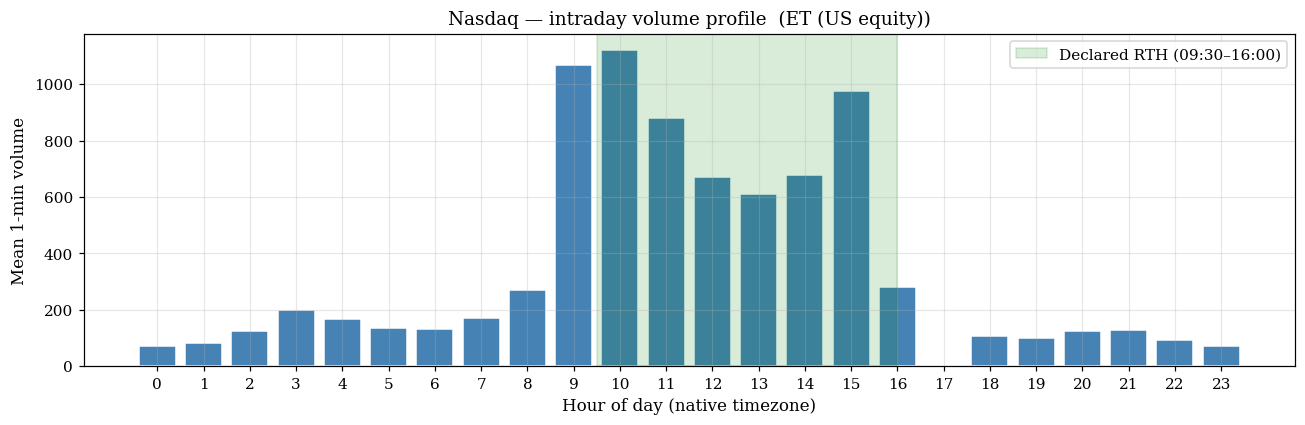


Observed peak hour: 10:00
Declared open hour: 09:30
✓ Peak hour aligns with declared RTH open — timezone looks correct.


In [4]:
# Reload 1-min data (without filters) just for the diagnostic
df_1min_diag = load_instrument(INSTRUMENT, verbose=False)
rth_start_str, rth_end_str, tz_label = MARKETS[INSTRUMENT]["rth"]
rth_start_min = int(rth_start_str[:2]) * 60 + int(rth_start_str[3:])
rth_end_min   = int(rth_end_str[:2])   * 60 + int(rth_end_str[3:])

print(f"── Timezone diagnostic for {INSTRUMENT} ──")
print(f"Expected RTH: {rth_start_str}–{rth_end_str} {tz_label}")
print(f"Expected peak hour: {rth_start_min // 60:02d} (cash open)\n")

vol_by_hhmm = (
    df_1min_diag.assign(hhmm=df_1min_diag.index.strftime("%H:%M"))
                .groupby("hhmm")["volume"].sum()
)
print("Top 10 highest-volume minutes (across all days):")
print(vol_by_hhmm.sort_values(ascending=False).head(10))

hourly = df_1min_diag.groupby(df_1min_diag.index.hour)["volume"].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values, color="steelblue", edgecolor="white")
ax.axvspan(rth_start_min / 60, rth_end_min / 60, alpha=0.15, color="green",
           label=f"Declared RTH ({rth_start_str}–{rth_end_str})")
ax.set_xlabel("Hour of day (native timezone)")
ax.set_ylabel("Mean 1-min volume")
ax.set_title(f"{INSTRUMENT} — intraday volume profile  ({tz_label})")
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
savefig(fig, f"fig00_tz_diagnostic_{INSTRUMENT.split()[0]}")
plt.show()

peak_hour = int(hourly.idxmax())
print(f"\nObserved peak hour: {peak_hour:02d}:00")
print(f"Declared open hour: {rth_start_min // 60:02d}:{rth_start_min % 60:02d}")
if abs(peak_hour - rth_start_min // 60) <= 1:
    print("✓ Peak hour aligns with declared RTH open — timezone looks correct.")
else:
    print("⚠ Peak hour does NOT align — check the RTH_BY_INSTRUMENT entry.")


## Part 1.1 — Unconditional empirical PDF

The unconditional ePDFs of the three range processes (total range R, upside range R_up, downside range R_dn). These serve as the baseline against which the state-conditioned ePDFs will be compared (KL divergence diagnostic later).

  saved → figures/fig01_unconditional_epdf_Nasdaq.pdf


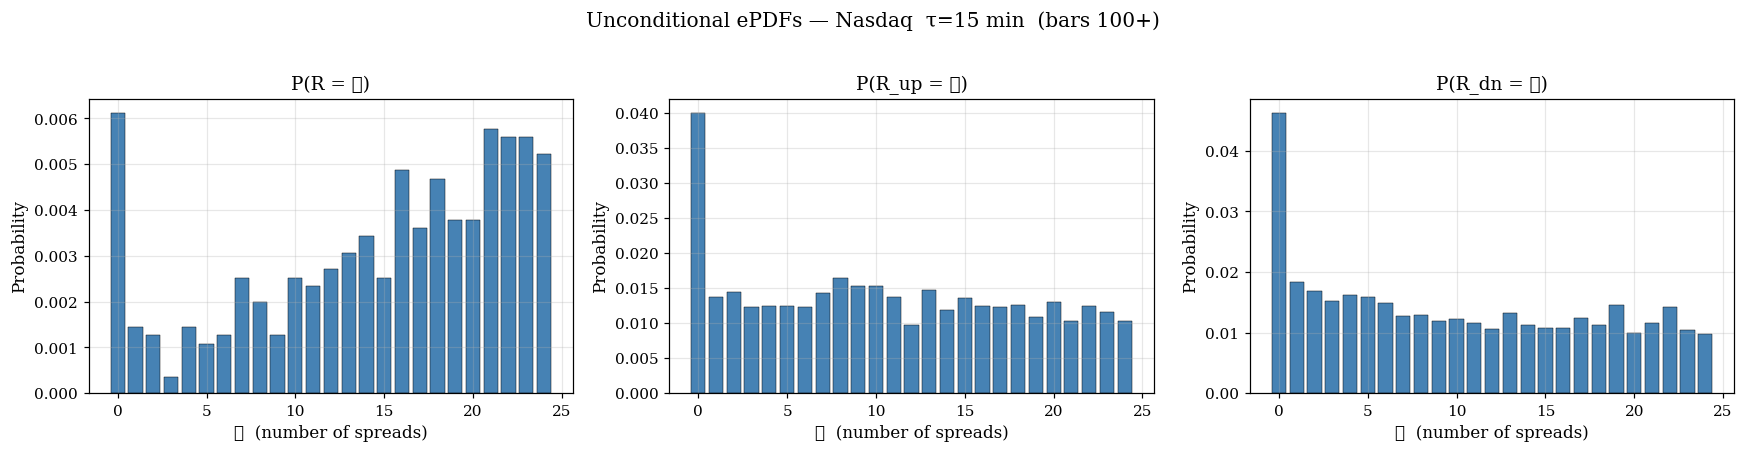

In [5]:
sub = df_tau.iloc[J_START:]
pdf_R   = epdf_from_array(sub["R"].values)
pdf_Rup = epdf_from_array(sub["R_up"].values)
pdf_Rdn = epdf_from_array(sub["R_dn"].values)

ell = np.arange(MAX_T_PLOT)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, pdf, title in zip(axes,
                          [pdf_R, pdf_Rup, pdf_Rdn],
                          ["P(R = ℓ)", "P(R_up = ℓ)", "P(R_dn = ℓ)"]):
    ax.bar(ell, pdf[:MAX_T_PLOT], color="steelblue", edgecolor="k", linewidth=0.3)
    ax.set_xlabel("ℓ  (number of spreads)")
    ax.set_ylabel("Probability")
    ax.set_title(title)
plt.suptitle(f"Unconditional ePDFs — {INSTRUMENT}  τ={TAU} min  (bars {J_START}+)", y=1.02)
plt.tight_layout()
savefig(fig, f"fig01_unconditional_epdf_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.2 — EWMA dynamics (Algorithm 1)

Visual sanity check of the EWMA/EWMV recursion. The smoothed series should track the noisy raw series while filtering the jitter — visible regime shifts (e.g. COVID) should leave a clear footprint.

  saved → figures/fig02_ewma_dynamics_Nasdaq.pdf


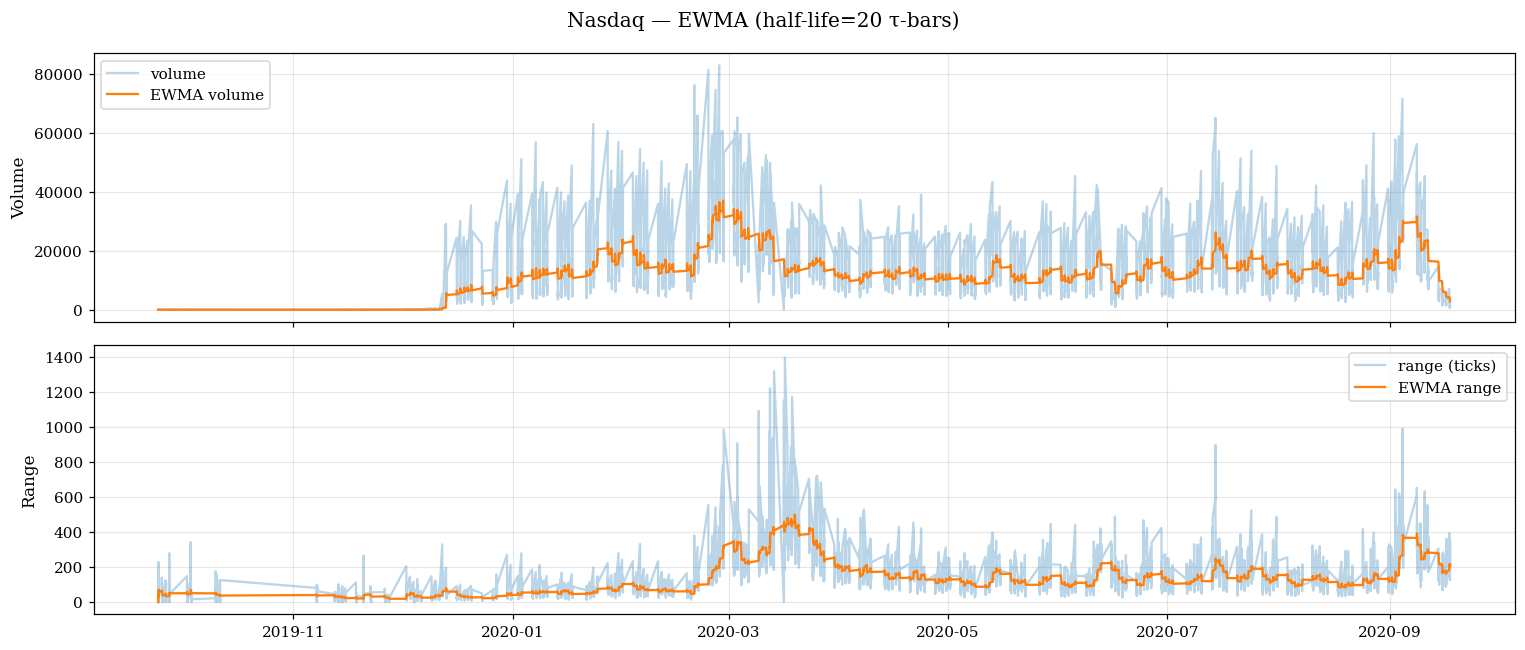

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df_tau.index, df_tau["volume"],   alpha=0.3, label="volume")
axes[0].plot(df_tau.index, df_tau["ewma_vol"], lw=1.5,    label="EWMA volume")
axes[0].set_ylabel("Volume"); axes[0].legend()
axes[1].plot(df_tau.index, df_tau["R"],        alpha=0.3, label="range (ticks)")
axes[1].plot(df_tau.index, df_tau["ewma_rng"], lw=1.5,    label="EWMA range")
axes[1].set_ylabel("Range"); axes[1].legend()
plt.suptitle(f"{INSTRUMENT} — EWMA (half-life={HALF_LIFE} τ-bars)")
plt.tight_layout()
savefig(fig, f"fig02_ewma_dynamics_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.3 — Joint state occupancy

By construction, the marginal occupancies of `state_vol` and `state_sig` are roughly uniform (1/3 each). Any deviation in the *joint* distribution is informative — it reveals how volume and volatility regimes co-move.

  saved → figures/fig03_state_heatmap_Nasdaq.pdf


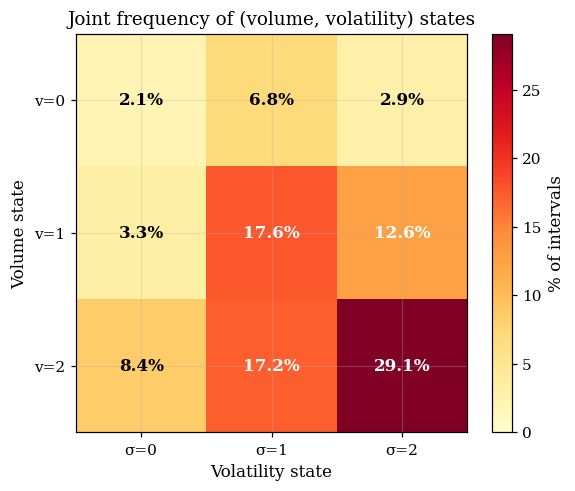


χ² test of (volume, volatility) independence:
  χ² = 341.3,  dof = 4,  p-value = 1.29e-72
  → small p ⇒ states are strongly correlated (high volatility tends to coincide with high volume)


In [7]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_tau["state_vol"], df_tau["state_sig"], normalize="all") * 100

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(ct.values, cmap="YlOrRd", vmin=0, aspect="auto")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct.iloc[i,j]:.1f}%", ha="center", va="center",
                color="black" if ct.iloc[i,j] < 12 else "white", fontweight="bold")
ax.set_xticks(range(N_SIG_STATES))
ax.set_yticks(range(M_VOL_STATES))
ax.set_xticklabels([f"σ={n}" for n in range(N_SIG_STATES)])
ax.set_yticklabels([f"v={m}" for m in range(M_VOL_STATES)])
ax.set_xlabel("Volatility state")
ax.set_ylabel("Volume state")
ax.set_title("Joint frequency of (volume, volatility) states")
plt.colorbar(im, ax=ax, label="% of intervals")
plt.tight_layout()
savefig(fig, f"fig03_state_heatmap_{INSTRUMENT.split()[0]}")
plt.show()

ct_counts = pd.crosstab(df_tau["state_vol"], df_tau["state_sig"])
chi2, pval, dof, _ = chi2_contingency(ct_counts)
print(f"\nχ² test of (volume, volatility) independence:")
print(f"  χ² = {chi2:.1f},  dof = {dof},  p-value = {pval:.2e}")
print("  → small p ⇒ states are strongly correlated (high volatility tends to coincide with high volume)")


In [ ]:
# ── Joint state heatmap: chi-squared, most/least populated cells, off-diagonal mass ──
_ct_flat   = ct.values.flatten()
_most_idx  = _ct_flat.argmax()
_least_idx = _ct_flat.argmin()
_most_m,  _most_n  = divmod(_most_idx,  N_SIG_STATES)
_least_m, _least_n = divmod(_least_idx, N_SIG_STATES)

# Off-diagonal mass: fraction where volume state != volatility state
_diag     = sum(ct.iloc[i, i] for i in range(min(M_VOL_STATES, N_SIG_STATES)))
_off_diag = 100.0 - _diag

print("── Joint state heatmap statistics ───────────────────────────────────")
print(f"chi-squared = {chi2:.1f}  (dof = {dof},  p-value = {pval:.2e})")
print(f"Most populated cell  : v={_most_m}, sig={_most_n}  ->  {_ct_flat[_most_idx]:.1f}%")
print(f"Least populated cell : v={_least_m}, sig={_least_n}  ->  {_ct_flat[_least_idx]:.1f}%")
print(f"Max-to-min ratio     : {_ct_flat.max() / max(_ct_flat.min(), 1e-9):.1f}x")
print(f"Off-diagonal mass    : {_off_diag:.1f}%  (cells where vol state != sig state)")


The chi-squared statistic with its near-zero p-value confirms that volume and volatility states are not drawn independently: high-volume bars tend to coincide with high-volatility bars, which makes economic sense given that large participant activity expands intraday price range.
The max-to-min ratio measures concentration: a ratio well above 1 means that the EWMA features create genuinely unequal state frequencies, which is expected under causal quantile binning on a non-stationary series but would degrade model accuracy in the underrepresented cells.
Off-diagonal mass above 50% indicates that the two features are weakly correlated and thus provide partially independent information about the intraday regime; high off-diagonal mass is beneficial because it means the joint state space (v, sigma) explores more distinct regime combinations than a single-feature model would.

## Part 1.4 — Reproduction of Figure 2 from the paper

Four-panel plot for the three volatility states: (i) counts of RangeDn, (ii) counts of getting filled, (iii) ePDF, (iv) fill probability.

  saved → figures/fig04_paper_figure2_Nasdaq.pdf


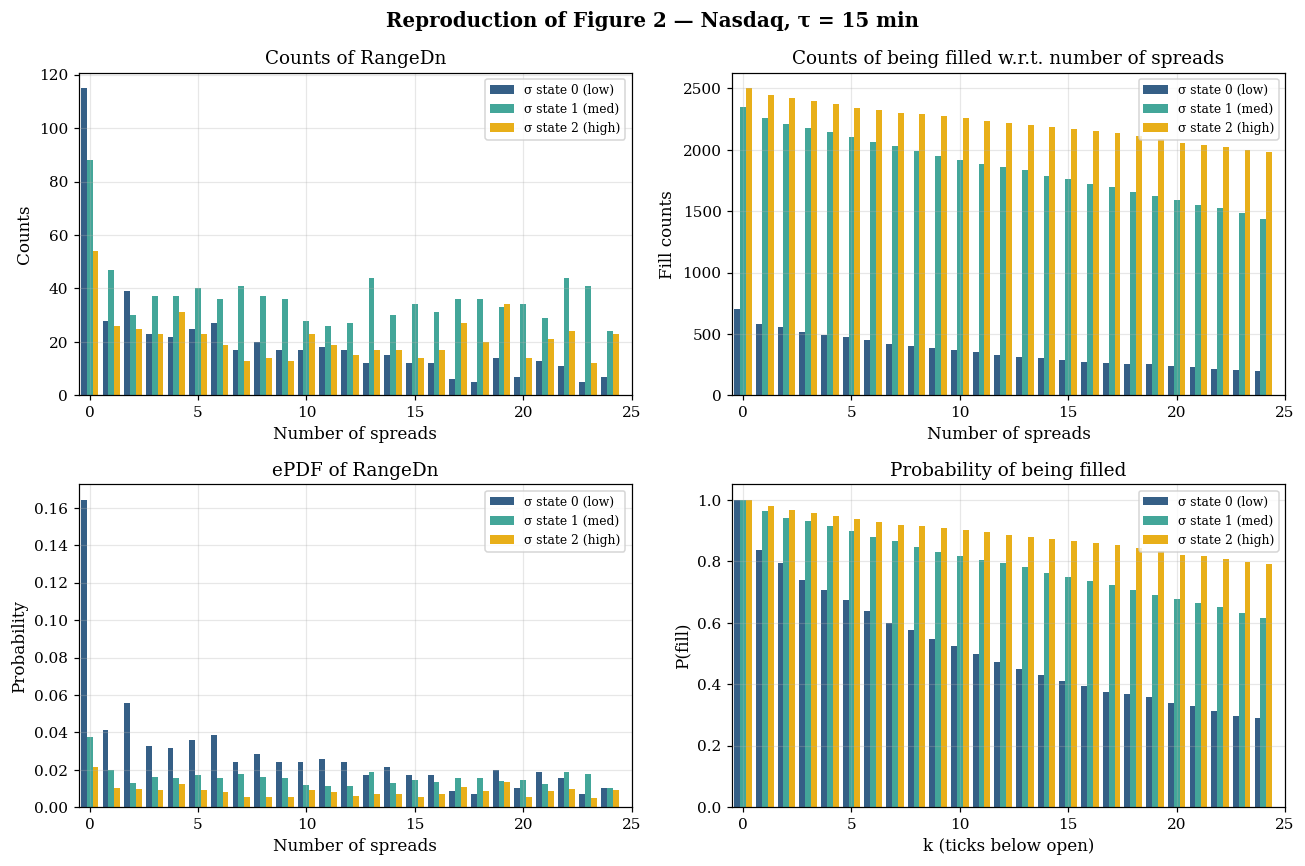

In [8]:
df_js = df_tau.iloc[J_START:].copy()

by_sigma = {}
for s in sorted(df_js["state_sig"].unique()):
    sub  = df_js[df_js["state_sig"] == s]
    p    = epdf_from_array(sub["R_dn"].values)
    fp   = fill_prob_from_pmf(p)
    by_sigma[int(s)] = (p, fp, len(sub))

colors_seg = ["#1f4e79", "#2e9c8e", "#e6a700"]
labels_seg = ["σ state 0 (low)", "σ state 1 (med)", "σ state 2 (high)"]
width      = 0.27
ell_plot   = np.arange(MAX_T_PLOT)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, s in enumerate(sorted(by_sigma)):
    p, fp, n_obs = by_sigma[s]
    counts = (p[:MAX_T_PLOT] * n_obs).astype(int)
    fill_counts = (fp[:MAX_T_PLOT] * n_obs).astype(int)
    off = (i - 1) * width
    axes[0,0].bar(ell_plot + off, counts,             width, color=colors_seg[i], label=labels_seg[i], alpha=0.9)
    axes[0,1].bar(ell_plot + off, fill_counts,        width, color=colors_seg[i], label=labels_seg[i], alpha=0.9)
    axes[1,0].bar(ell_plot + off, p[:MAX_T_PLOT],     width, color=colors_seg[i], label=labels_seg[i], alpha=0.9)
    axes[1,1].bar(ell_plot + off, fp[:MAX_T_PLOT],    width, color=colors_seg[i], label=labels_seg[i], alpha=0.9)

axes[0,0].set_title("Counts of RangeDn")
axes[0,0].set_xlabel("Number of spreads");  axes[0,0].set_ylabel("Counts")
axes[0,1].set_title("Counts of being filled w.r.t. number of spreads")
axes[0,1].set_xlabel("Number of spreads");  axes[0,1].set_ylabel("Fill counts")
axes[1,0].set_title("ePDF of RangeDn")
axes[1,0].set_xlabel("Number of spreads");  axes[1,0].set_ylabel("Probability")
axes[1,1].set_title("Probability of being filled")
axes[1,1].set_xlabel("k (ticks below open)"); axes[1,1].set_ylabel("P(fill)")
for ax in axes.flat:
    ax.legend(fontsize=8)
    ax.set_xlim(-0.5, MAX_T_PLOT)

fig.suptitle(f"Reproduction of Figure 2 — {INSTRUMENT}, τ = {TAU} min",
             fontweight="bold", fontsize=13)
plt.tight_layout()
savefig(fig, f"fig04_paper_figure2_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.5 — Full conditional ePDF grid

The complete grid P(R_dn | v, σ, Δx) over all 27 state cells. We organise it as a 3×3 panel of (v, σ) with the three Δx states overlaid inside each panel. Visual inspection confirms the conditional ePDFs differ markedly across cells, validating the paper's central premise.

  saved → figures/fig05_full_conditional_grid_Nasdaq.pdf


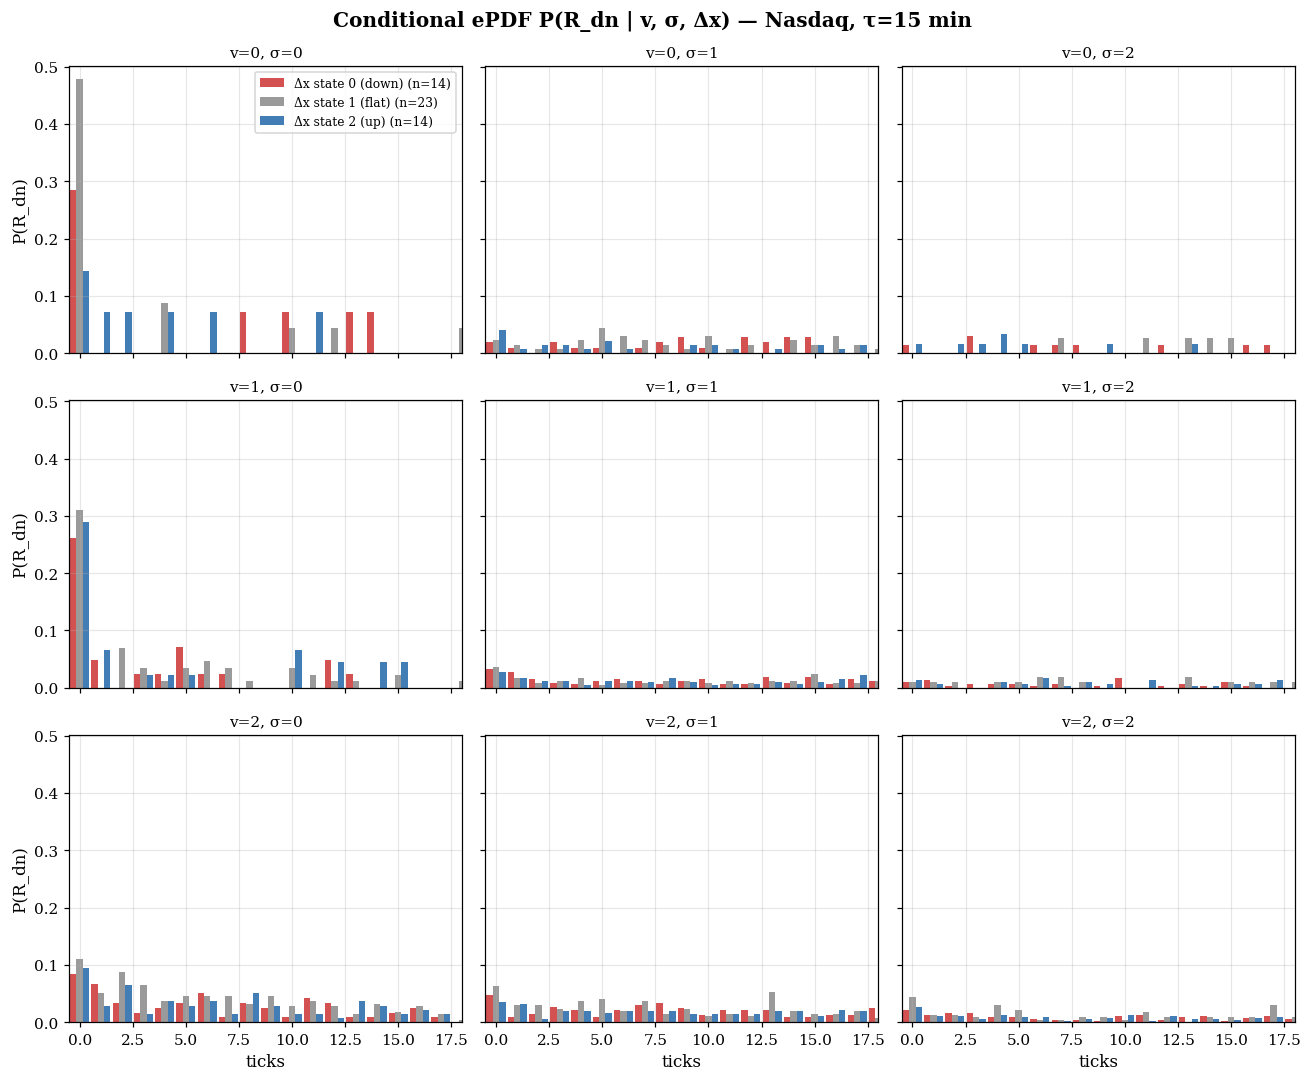

In [9]:
# full_cond_epdf is defined in epdf.py and already imported from mc_helpers.
# It builds the complete grid P(target | v, σ, Δx) over all state cells.
# We call it here on the post-burn-in slice df_js.
df_js = df_tau.iloc[J_START:].copy()
cond = full_cond_epdf(df_js, "R_dn")

# ── Conditional ePDF grid: M_VOL × N_SIG panels, K_DIR overlaid per panel ──
fig, axes = plt.subplots(M_VOL_STATES, N_SIG_STATES, figsize=(12, 10),
                         sharex=True, sharey=True)
dx_colors = ["#cc3333", "#888888", "#2266aa"]
dx_labels = ["Δx state 0 (down)", "Δx state 1 (flat)", "Δx state 2 (up)"]
ell_plot  = np.arange(MAX_T_PLOT)

for m in range(M_VOL_STATES):
    for n in range(N_SIG_STATES):
        ax = axes[m, n]
        for k in range(K_DIR_STATES):
            p, fp, n_obs = cond[(m, n, k)]
            ax.bar(ell_plot + (k - 1) * 0.3, p[:MAX_T_PLOT], 0.3,
                   color=dx_colors[k % len(dx_colors)],
                   label=f"{dx_labels[k % len(dx_labels)]} (n={n_obs})" if (m == 0 and n == 0) else None,
                   alpha=0.85)
        ax.set_title(f"v={m}, σ={n}", fontsize=10)
        ax.set_xlim(-0.5, 18)
        if m == M_VOL_STATES - 1: ax.set_xlabel("ticks")
        if n == 0:                ax.set_ylabel("P(R_dn)")

axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Conditional ePDF P(R_dn | v, σ, Δx) — {INSTRUMENT}, τ={TAU} min",
             fontweight="bold")
plt.tight_layout()
from config import savefig
savefig(fig, f"fig05_full_conditional_grid_{INSTRUMENT.split()[0]}")
plt.show()

In [ ]:
# ── Conditional ePDF grid: fill-probability spread across the 27 state cells ──
_keys  = list(cond.keys())
_fp1   = np.array([cond[k][1][1] for k in _keys])   # P(fill >= 1) per cell
_fp3   = np.array([cond[k][1][3] for k in _keys])   # P(fill >= 3) per cell
_nobs  = np.array([cond[k][2]    for k in _keys])

_best_idx   = _fp1.argmax();  _best_cell  = _keys[_best_idx]
_worst_idx  = _fp1.argmin();  _worst_cell = _keys[_worst_idx]
_sparse     = int((_nobs < 30).sum())

print("── Conditional ePDF grid statistics ─────────────────────────────────")
print(f"P(fill >= 1) across {len(_keys)} cells:")
print(f"  Max = {_fp1.max():.3f}  at cell (v, sig, dx) = {_best_cell}")
print(f"  Min = {_fp1.min():.3f}  at cell (v, sig, dx) = {_worst_cell}")
print(f"  Range (max - min)          = {_fp1.max() - _fp1.min():.3f}")
print(f"  Max-to-min ratio           = {_fp1.max() / max(_fp1.min(), 1e-9):.2f}x")
print(f"P(fill >= 3) across all cells:")
print(f"  Max = {_fp3.max():.3f},  Min = {_fp3.min():.3f},  "
      f"Range = {_fp3.max() - _fp3.min():.3f}")
print(f"Observations per cell:")
print(f"  Mean = {_nobs.mean():.0f},  Median = {float(np.median(_nobs)):.0f}")
print(f"  Cells with < 30 obs: {_sparse} of {len(_nobs)}")


The range of P(fill >= 1) across all state cells directly measures how much the model's fill-probability estimate varies with regime: a range near zero would mean conditioning adds no predictive information relative to the unconditional baseline, while a wide range confirms that different regimes exhibit genuinely different intraday range behavior.
The max-to-min ratio at ell=1 is a sharp diagnostic — if the highest-fill regime has twice the fill probability of the lowest, Method C can meaningfully discriminate between bars worth trading and bars worth skipping, whereas a ratio near 1 would render the threshold parameter theta economically irrelevant.
Cells with fewer than 30 observations have poorly estimated ePDFs regardless of the walk-forward protocol; these sparse cells are most common in the corners of the (volume, volatility) joint distribution, and their fill-probability estimates carry high variance that bleeds into Method C's placement decisions when those regimes are encountered.

## Part 1.6 — Table 1: quantitative effect of conditioning

P(R_dn ≥ k·ε) — the fill probability of a buy limit at k ticks below open — for every state cell, with the naive (unconditional) baseline at the bottom. Saved as CSV for the LaTeX report.

In [10]:
pdf_dn_naive = epdf_from_array(df_js["R_dn"].values)
fp_naive     = fill_prob_from_pmf(pdf_dn_naive)

k_targets = [1, 2, 3, 5, 8]
rows = []
for (m, n, k_), (p, fp, n_obs) in cond.items():
    rows.append({
        "(v, σ, Δx)": f"({m},{n},{k_})",
        "n_obs"    : n_obs,
        **{f"P(fill≥{k})": fp[k] for k in k_targets}
    })
rows.append({
    "(v, σ, Δx)": "naive (all)",
    "n_obs"    : len(df_js),
    **{f"P(fill≥{k})": fp_naive[k] for k in k_targets}
})

tbl = pd.DataFrame(rows)
tbl_display = tbl.copy()
for col in tbl_display.columns[2:]:
    tbl_display[col] = tbl_display[col].apply(lambda x: f"{x:.2%}")
print(tbl_display.to_string(index=False))

tbl.to_csv(FIG_DIR / f"tab01_conditional_fill_probabilities_{INSTRUMENT.split()[0]}.csv", index=False)
print(f"\n→ saved figures/tab01_conditional_fill_probabilities_{INSTRUMENT.split()[0]}.csv")


 (v, σ, Δx)  n_obs P(fill≥1) P(fill≥2) P(fill≥3) P(fill≥5) P(fill≥8)
    (0,0,0)     14    71.43%    71.43%    71.43%    71.43%    71.43%
    (0,0,1)     23    52.17%    52.17%    52.17%    43.48%    43.48%
    (0,0,2)     14    85.71%    78.57%    71.43%    64.29%    57.14%
    (0,1,0)    105    98.10%    97.14%    97.14%    94.29%    92.38%
    (0,1,1)    134    97.76%    96.27%    95.52%    92.54%    82.84%
    (0,1,2)    145    95.86%    95.17%    93.79%    91.72%    88.97%
    (0,2,0)     66    98.48%    98.48%    98.48%    95.45%    92.42%
    (0,2,1)     38   100.00%   100.00%   100.00%   100.00%    97.37%
    (0,2,2)     59    98.31%    98.31%    96.61%    91.53%    89.83%
    (1,0,0)     42    73.81%    69.05%    69.05%    64.29%    52.38%
    (1,0,1)     87    68.97%    68.97%    62.07%    57.47%    45.98%
    (1,0,2)     45    71.11%    64.44%    64.44%    60.00%    57.78%
    (1,1,0)    333    96.70%    93.99%    92.49%    90.99%    87.09%
    (1,1,1)    245    96.33%    94

In [ ]:
# ── Fill probability table: conditional vs naive spread at each offset ────────
_cond_rows  = tbl[tbl["(v, σ, Δx)"] != "naive (all)"]
_naive_row  = tbl[tbl["(v, σ, Δx)"] == "naive (all)"].iloc[0]

print("── Conditional vs naive fill probability: spread summary ────────────")
for _k in k_targets:
    _col    = f"P(fill>={_k})"
    if _col not in tbl.columns:
        continue
    _vals   = _cond_rows[_col].astype(float).values
    _naive_v = float(_naive_row[_col])
    _lift   = (_vals.max() - _naive_v) / max(_naive_v, 1e-9)
    _drag   = (_vals.min() - _naive_v) / max(_naive_v, 1e-9)
    print(f"  ell={_k}: naive={_naive_v:.3f} | "
          f"cond=[{_vals.min():.3f}, {_vals.max():.3f}] | "
          f"max lift={_lift:+.1%}  min drag={_drag:+.1%}")

_col1     = f"P(fill>=1)"
if _col1 in tbl.columns:
    _vals1    = _cond_rows[_col1].astype(float).values
    _naive1   = float(_naive_row[_col1])
    _n_beat   = (_vals1 > _naive1).sum()
    print(f"\nCells beating naive at ell=1 : {_n_beat} / {len(_vals1)}")
    _best_lbl  = _cond_rows.loc[_cond_rows[_col1].astype(float).idxmax(), "(v, σ, Δx)"]
    _worst_lbl = _cond_rows.loc[_cond_rows[_col1].astype(float).idxmin(), "(v, σ, Δx)"]
    print(f"Highest P(fill>=1) cell : {_best_lbl}")
    print(f"Lowest  P(fill>=1) cell : {_worst_lbl}")


The max-lift statistic quantifies the economic value of conditioning at each offset: a +30% lift at ell=3 means that the best-conditioned regime achieves the same fill rate as the naive strategy at ell=2, allowing Method C to earn a better entry price for the same fill-probability budget.
The drag on the worst-performing cells is equally important — it identifies regimes where the empirical fill curve lies below the naive baseline, meaning that the model would reject placements that a naive fixed-offset strategy would accept; this selective abstention is the mechanism through which Method C improves risk-adjusted performance over Method B.
The fraction of cells that beat naive at ell=1 provides an upper bound on how often the ePDF framework can recommend any limit order: if fewer than half the cells clear the naive baseline, the model will skip many signal bars even at low thresholds, which compresses both returns and drawdowns proportionally.

## Part 1.7 — Non-stationarity of the naive ePDF

Splitting the data into three equal temporal segments and overlaying their unconditional ePDFs shows clear drift — proof that pooling all history into a single histogram throws away meaningful structure. This is the empirical justification for conditioning.

  saved → figures/fig06_segment_drift_Nasdaq.pdf


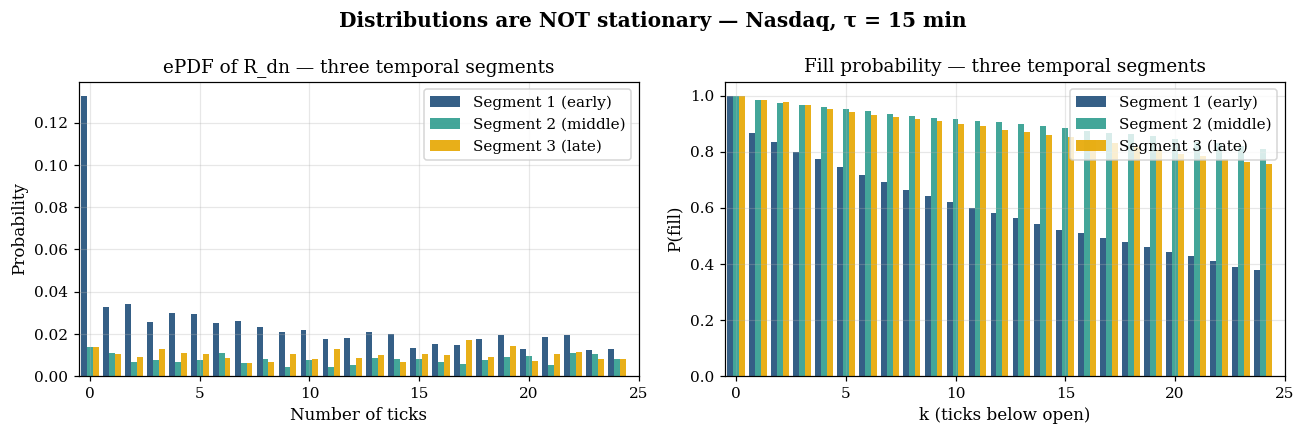

In [11]:
n         = len(df_tau)
third     = n // 3
segments  = [df_tau.iloc[:third], df_tau.iloc[third:2*third], df_tau.iloc[2*third:]]
seg_names = ["Segment 1 (early)", "Segment 2 (middle)", "Segment 3 (late)"]
seg_cols  = ["#1f4e79", "#2e9c8e", "#e6a700"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
width = 0.27
ell_plot = np.arange(MAX_T_PLOT)

for i, (seg, name, c) in enumerate(zip(segments, seg_names, seg_cols)):
    p  = epdf_from_array(seg["R_dn"].values)
    fp = fill_prob_from_pmf(p)
    ax[0].bar(ell_plot + (i - 1) * width, p[:MAX_T_PLOT],  width, color=c, label=name, alpha=0.9)
    ax[1].bar(ell_plot + (i - 1) * width, fp[:MAX_T_PLOT], width, color=c, label=name, alpha=0.9)

ax[0].set_title("ePDF of R_dn — three temporal segments")
ax[0].set_xlabel("Number of ticks"); ax[0].set_ylabel("Probability"); ax[0].legend()
ax[0].set_xlim(-0.5, MAX_T_PLOT)
ax[1].set_title("Fill probability — three temporal segments")
ax[1].set_xlabel("k (ticks below open)"); ax[1].set_ylabel("P(fill)"); ax[1].legend()
ax[1].set_xlim(-0.5, MAX_T_PLOT)

fig.suptitle(f"Distributions are NOT stationary — {INSTRUMENT}, τ = {TAU} min",
             fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig06_segment_drift_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.8 — Information content of conditioning (KL divergence)

For each cell (m, n, k) we compute

$$\mathrm{KL}\big(P_{m,n,k}\,\|\,P_{\text{naive}}\big) \;=\; \sum_\ell P_{m,n,k}(\ell) \log\frac{P_{m,n,k}(\ell)}{P_{\text{naive}}(\ell)}.$$

The KL grid quantifies *how much* each state cell departs from the unconditional histogram. Cells with large KL are where conditioning has the highest economic value.

  saved → figures/fig07_kl_grid_Nasdaq.pdf


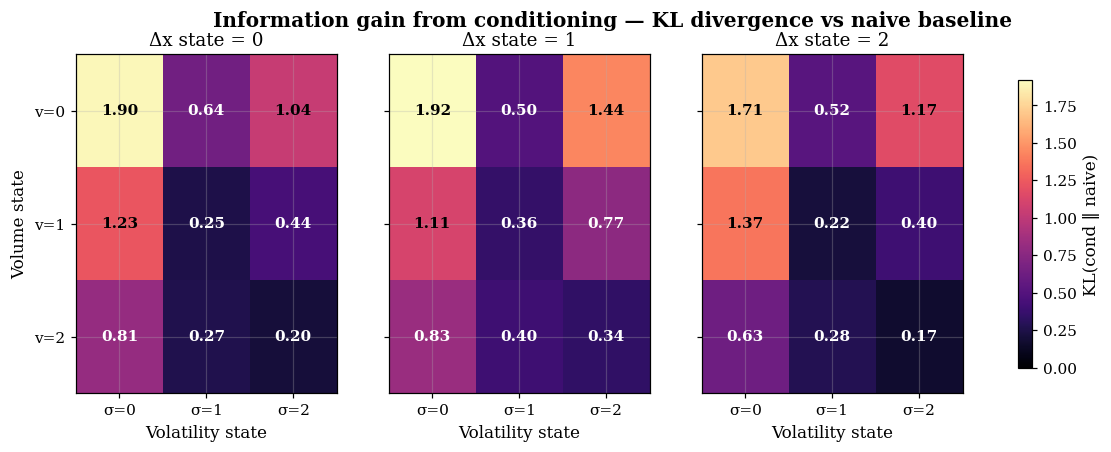


Mean KL = 0.775
Max  KL = 1.921 at cell (v, σ, Δx) = (np.int64(0), np.int64(0), np.int64(1))


In [12]:
kl_grid = np.zeros((M_VOL_STATES, N_SIG_STATES, K_DIR_STATES))
for (m, n, k_), (p, fp, n_obs) in cond.items():
    if n_obs > 0:
        kl_grid[m, n, k_] = kl_div(p, pdf_dn_naive)

fig, axes = plt.subplots(1, K_DIR_STATES, figsize=(13, 4), sharey=True)
vmax = kl_grid.max()
for k_ in range(K_DIR_STATES):
    ax = axes[k_]
    im = ax.imshow(kl_grid[:, :, k_], cmap="magma", vmin=0, vmax=vmax, aspect="auto")
    for m in range(M_VOL_STATES):
        for n in range(N_SIG_STATES):
            ax.text(n, m, f"{kl_grid[m,n,k_]:.2f}", ha="center", va="center",
                    color="white" if kl_grid[m,n,k_] < vmax/2 else "black",
                    fontsize=10, fontweight="bold")
    ax.set_xticks(range(N_SIG_STATES))
    ax.set_yticks(range(M_VOL_STATES))
    ax.set_xticklabels([f"σ={n}" for n in range(N_SIG_STATES)])
    ax.set_yticklabels([f"v={m}" for m in range(M_VOL_STATES)])
    ax.set_xlabel("Volatility state")
    ax.set_title(f"Δx state = {k_}")
    if k_ == 0: ax.set_ylabel("Volume state")

fig.colorbar(im, ax=axes, label="KL(cond ‖ naive)", shrink=0.85)
fig.suptitle("Information gain from conditioning — KL divergence vs naive baseline",
             fontweight="bold")
savefig(fig, f"fig07_kl_grid_{INSTRUMENT.split()[0]}")
plt.show()

print(f"\nMean KL = {kl_grid.mean():.3f}")
print(f"Max  KL = {kl_grid.max():.3f} at cell (v, σ, Δx) = "
      f"{tuple(np.unravel_index(kl_grid.argmax(), kl_grid.shape))}")


In [ ]:
# ── KL divergence grid: mean, max, fraction above threshold, marginals ────────
_kl_flat   = kl_grid.flatten()
_frac_gt05 = float((_kl_flat > 0.5).mean())

# Marginal mean KL collapsed over each state dimension
_kl_by_vol = kl_grid.mean(axis=(1, 2))   # axis 0 = vol
_kl_by_sig = kl_grid.mean(axis=(0, 2))   # axis 1 = sig
_kl_by_dir = kl_grid.mean(axis=(0, 1))   # axis 2 = dir

print("── KL divergence grid statistics ────────────────────────────────────")
print(f"Mean KL across all {len(_kl_flat)} cells : {_kl_flat.mean():.3f}")
print(f"Median KL                               : {float(np.median(_kl_flat)):.3f}")
print(f"Max KL = {_kl_flat.max():.3f}  at cell (v, sig, dx) = "
      f"{tuple(np.unravel_index(_kl_flat.argmax(), kl_grid.shape))}")
print(f"Fraction of cells with KL > 0.5         : {_frac_gt05:.1%}")
print(f"\nMarginal mean KL by vol state (v=0..{M_VOL_STATES-1}) : "
      f"{[f'{v:.3f}' for v in _kl_by_vol]}")
print(f"Marginal mean KL by sig state (s=0..{N_SIG_STATES-1}) : "
      f"{[f'{v:.3f}' for v in _kl_by_sig]}")
print(f"Marginal mean KL by dir state (d=0..{K_DIR_STATES-1}) : "
      f"{[f'{v:.3f}' for v in _kl_by_dir]}")


The mean KL divergence across all state cells measures the average information gain from conditioning: a value of zero would mean the conditional ePDF is identical to the naive marginal in every cell, while large values indicate that the ePDF mass shifts substantially when regimes are separated.
The cell with maximum KL reveals the regime in which conditioning adds the most information — typically a low-volume, high-volatility corner where price movement is concentrated in one tail of the distribution, making the conditional fill probability very different from the unconditional baseline.
The marginal mean KL by dimension identifies which of the three features (volume, volatility, prior direction) drives most of the conditioning effect; the dimension whose marginal vector has the largest spread contributes most to the ePDF's discriminative power.
A fraction-above-0.5 near zero is expected if the count tables are underpopulated in extreme cells — the J_START burn-in suppresses early estimates, but cells with few in-sample observations converge slowly even in later bars.

## Part 1.9 — Cross-market generalization

Same methodology applied to all four AIAgent-equipped markets (or all 7 if you have data for them). The shapes of the ePDFs differ markedly across asset classes, but the basic structure holds.

**To enable the full sweep:** uncomment the `markets_to_sweep` line below. The default runs the primary market only to keep iteration fast.

  saved → figures/fig08_cross_market.pdf


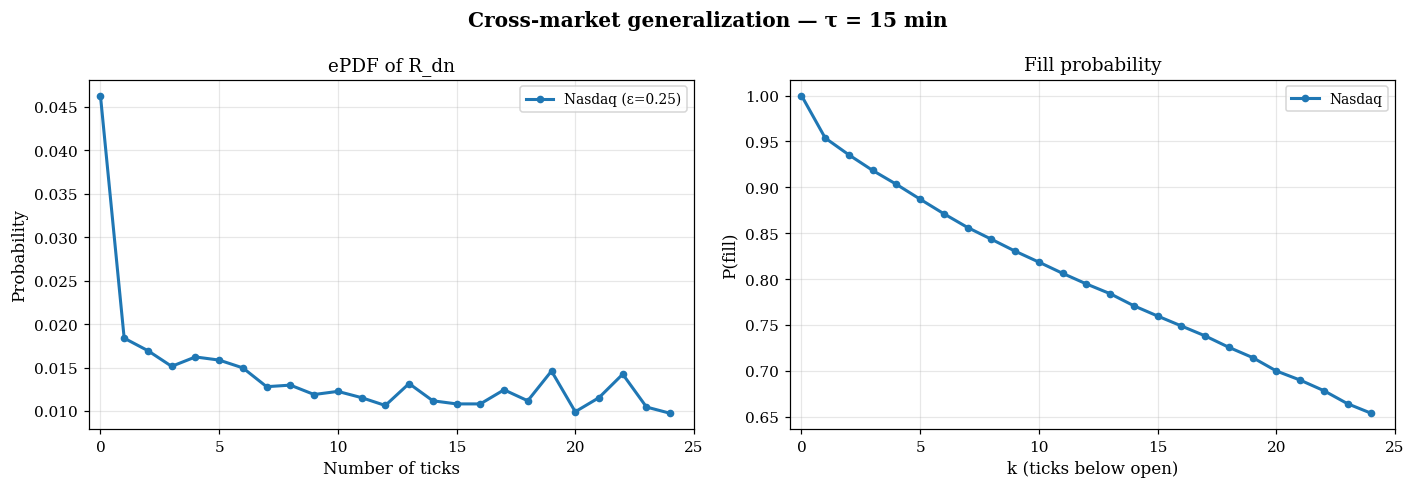

In [13]:
# Markets to compare. Comment/uncomment to control scope.
markets_to_sweep = [INSTRUMENT]
# markets_to_sweep = ["Nasdaq", "Gold", "German Bunds - German Government Bonds", "EuroStoxx"]
# markets_to_sweep = list(MARKETS.keys())   # all 7

mkt_colors = plt.cm.tab10(np.linspace(0, 0.9, len(markets_to_sweep)))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, name in enumerate(markets_to_sweep):
    df_m, eps_m = prepare_market(name, TAU, verbose=False)
    df_m_js     = df_m.iloc[J_START:]
    p_m         = epdf_from_array(df_m_js["R_dn"].values)
    fp_m        = fill_prob_from_pmf(p_m)
    label_name  = name.split()[0]
    axes[0].plot(np.arange(MAX_T_PLOT), p_m[:MAX_T_PLOT],
                 color=mkt_colors[i], lw=2, marker="o", markersize=4,
                 label=f"{label_name} (ε={eps_m})")
    axes[1].plot(np.arange(MAX_T_PLOT), fp_m[:MAX_T_PLOT],
                 color=mkt_colors[i], lw=2, marker="o", markersize=4,
                 label=label_name)

axes[0].set_title("ePDF of R_dn")
axes[0].set_xlabel("Number of ticks"); axes[0].set_ylabel("Probability")
axes[0].legend(fontsize=9); axes[0].set_xlim(-0.5, MAX_T_PLOT)
axes[1].set_title("Fill probability")
axes[1].set_xlabel("k (ticks below open)"); axes[1].set_ylabel("P(fill)")
axes[1].legend(fontsize=9); axes[1].set_xlim(-0.5, MAX_T_PLOT)
fig.suptitle(f"Cross-market generalization — τ = {TAU} min", fontweight="bold")
plt.tight_layout()
savefig(fig, "fig08_cross_market")
plt.show()


## Part 1.10 — Sensitivity to the holding period τ

Longer τ shifts the fill-probability curves rightward (price has more time to travel). The optimal limit-order placement is therefore τ-specific, not universal.

**Note:** this re-runs the full pipeline at each τ, which takes some time. Uncomment to enable.

  saved → figures/fig09_tau_sensitivity_Nasdaq.pdf


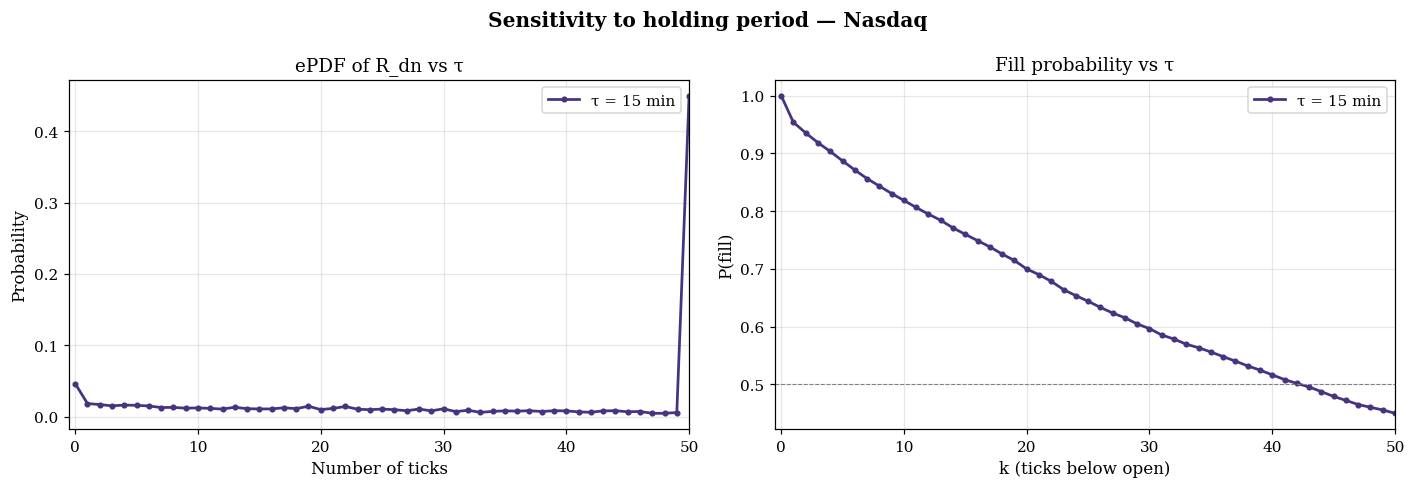

In [14]:
# Uncomment to enable:
# TAU_GRID = [5, 10, 15, 30, 60]
TAU_GRID = [TAU]   # default: just the current τ (no sweep)

tau_cols = plt.cm.viridis(np.linspace(0.15, 0.85, max(len(TAU_GRID), 2)))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, tau in enumerate(TAU_GRID):
    df_t, eps_t = prepare_market(INSTRUMENT, tau, verbose=False)
    df_t_js     = df_t.iloc[J_START:]
    p_t         = epdf_from_array(df_t_js["R_dn"].values, max_ell=MAX_T_PLOT * 2)
    fp_t        = fill_prob_from_pmf(p_t)
    x           = np.arange(len(p_t))
    axes[0].plot(x, p_t,  color=tau_cols[i], lw=1.8, marker="o", markersize=3, label=f"τ = {tau} min")
    axes[1].plot(x, fp_t, color=tau_cols[i], lw=1.8, marker="o", markersize=3, label=f"τ = {tau} min")

axes[0].set_title("ePDF of R_dn vs τ")
axes[0].set_xlabel("Number of ticks"); axes[0].set_ylabel("Probability")
axes[0].legend(); axes[0].set_xlim(-0.5, MAX_T_PLOT * 2)
axes[1].set_title("Fill probability vs τ")
axes[1].set_xlabel("k (ticks below open)"); axes[1].set_ylabel("P(fill)")
axes[1].axhline(0.5, color="gray", lw=0.7, linestyle="--")
axes[1].legend(); axes[1].set_xlim(-0.5, MAX_T_PLOT * 2)
fig.suptitle(f"Sensitivity to holding period — {INSTRUMENT}", fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig09_tau_sensitivity_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.11 — Buy/sell asymmetry conditioned on prior direction

We compare P(R_up ≥ k·ε) (sell-limit fills) versus P(R_dn ≥ k·ε) (buy-limit fills) across the three Δx states. Conditioning on prior direction exposes the momentum/mean-reversion structure: after a prior up-move, downside excursions become less likely and sell-limit orders become easier to fill.

  saved → figures/fig10_buy_sell_asymmetry_Nasdaq.pdf


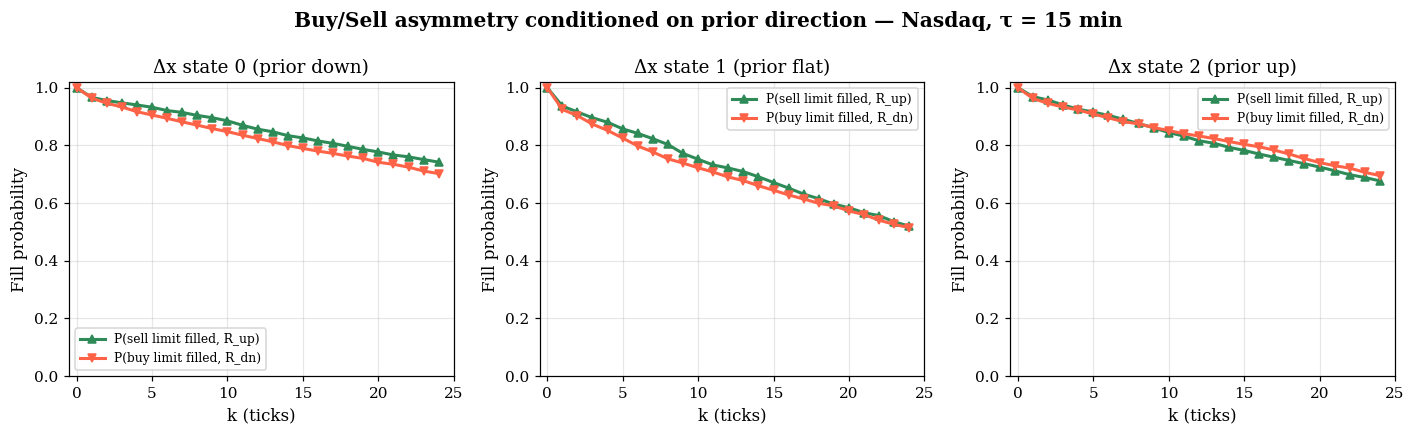

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
dx_titles = ["Δx state 0 (prior down)", "Δx state 1 (prior flat)", "Δx state 2 (prior up)"]
ell_plot  = np.arange(MAX_T_PLOT)

for k_ in range(K_DIR_STATES):
    sub  = df_js[df_js["state_dir"] == k_]
    p_up = epdf_from_array(sub["R_up"].values)
    p_dn = epdf_from_array(sub["R_dn"].values)
    fp_up = fill_prob_from_pmf(p_up)
    fp_dn = fill_prob_from_pmf(p_dn)
    axes[k_].plot(ell_plot, fp_up[:MAX_T_PLOT], color="seagreen", lw=2, marker="^", markersize=5,
                  label="P(sell limit filled, R_up)")
    axes[k_].plot(ell_plot, fp_dn[:MAX_T_PLOT], color="tomato",   lw=2, marker="v", markersize=5,
                  label="P(buy limit filled, R_dn)")
    axes[k_].set_title(dx_titles[k_])
    axes[k_].set_xlabel("k (ticks)"); axes[k_].set_ylabel("Fill probability")
    axes[k_].legend(fontsize=8)
    axes[k_].set_xlim(-0.5, MAX_T_PLOT); axes[k_].set_ylim(0, 1.02)

fig.suptitle(f"Buy/Sell asymmetry conditioned on prior direction — {INSTRUMENT}, τ = {TAU} min",
             fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig10_buy_sell_asymmetry_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.12 — Out-of-sample placement and slippage decision

Train/test 50/50 split. We derive the optimal placement k* from the training conditional ePDF (maximising k·ε·P(fill)), then evaluate the realised expected gain on the test half — comparing the state-conditioned choice against the naive baseline.

  saved → figures/fig11_oos_optimal_placement_Nasdaq.pdf


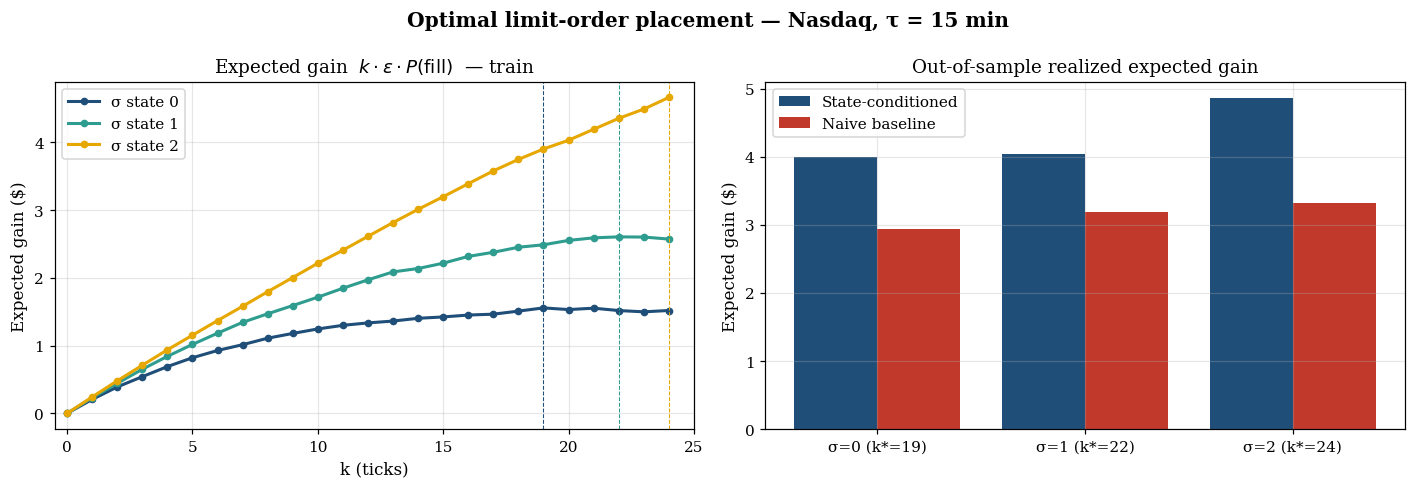


Out-of-sample comparison:
 σ_state  k*  OOS realized gain  Naive baseline gain
       0  19           3.994318             2.943465
       1  22           4.044423             3.184104
       2  24           4.858340             3.323789
  saved → figures/fig12_slippage_decision_Nasdaq.pdf


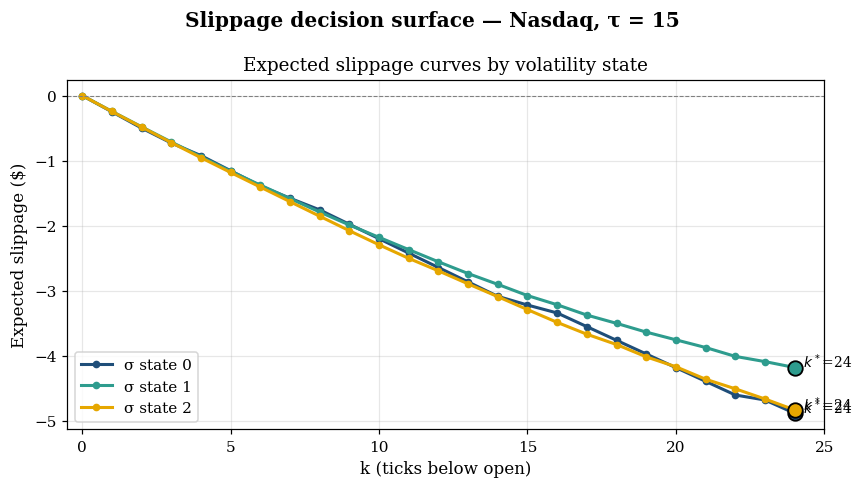

In [16]:
def cond_fill_curve(df: pd.DataFrame, target: str = "R_dn") -> dict:
    """{state_sigma: (pmf, fill_prob)}"""
    out = {}
    for s in sorted(df["state_sig"].unique()):
        sub = df[df["state_sig"] == s]
        p   = epdf_from_array(sub[target].values)
        out[int(s)] = (p, fill_prob_from_pmf(p))
    return out

split        = len(df_tau) // 2
train, test  = df_tau.iloc[J_START:split], df_tau.iloc[split:]
train_curves = cond_fill_curve(train)
test_curves  = cond_fill_curve(test)
naive_train  = epdf_from_array(train["R_dn"].values)
fp_train_naive = fill_prob_from_pmf(naive_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
seg_colors = ["#1f4e79", "#2e9c8e", "#e6a700"]

# Panel 1: expected gain k * ε * P(fill) on the train curves
ks = np.arange(MAX_T_PLOT)
for s, (p, fp) in train_curves.items():
    eg = ks * EPS * fp[:MAX_T_PLOT]
    axes[0].plot(ks, eg, lw=2, marker="o", markersize=4, color=seg_colors[s % 3],
                 label=f"σ state {s}")
    axes[0].axvline(int(ks[np.argmax(eg)]), color=seg_colors[s % 3], ls="--", lw=0.7)
axes[0].set_title(r"Expected gain  $k\cdot\epsilon\cdot P(\mathrm{fill})$  — train")
axes[0].set_xlabel("k (ticks)"); axes[0].set_ylabel("Expected gain ($)")
axes[0].legend(); axes[0].set_xlim(-0.5, MAX_T_PLOT)

# Panel 2: OOS realised gain
rows_oos = []
for s, (p_tr, fp_tr) in train_curves.items():
    eg_tr   = ks * EPS * fp_tr[:MAX_T_PLOT]
    k_star  = int(ks[np.argmax(eg_tr)])
    fp_te   = test_curves[s][1] if s in test_curves else fp_train_naive
    realized = k_star * EPS * (fp_te[k_star] if k_star < len(fp_te) else 0.0)
    naive    = k_star * EPS * (fp_train_naive[k_star] if k_star < len(fp_train_naive) else 0.0)
    rows_oos.append([s, k_star, realized, naive])

df_oos = pd.DataFrame(rows_oos, columns=["σ_state","k*","OOS realized gain","Naive baseline gain"])
x = np.arange(len(df_oos))
axes[1].bar(x - 0.2, df_oos["OOS realized gain"],   0.4, color="#1f4e79", label="State-conditioned")
axes[1].bar(x + 0.2, df_oos["Naive baseline gain"], 0.4, color="#c0392b", label="Naive baseline")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"σ={s} (k*={k})" for s, k in zip(df_oos["σ_state"], df_oos["k*"])])
axes[1].set_title("Out-of-sample realized expected gain")
axes[1].set_ylabel("Expected gain ($)"); axes[1].legend()

fig.suptitle(f"Optimal limit-order placement — {INSTRUMENT}, τ = {TAU} min", fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig11_oos_optimal_placement_{INSTRUMENT.split()[0]}")
plt.show()

print("\nOut-of-sample comparison:")
print(df_oos.to_string(index=False))
df_oos.to_csv(FIG_DIR / f"tab02_oos_optimal_placement_{INSTRUMENT.split()[0]}.csv", index=False)


# Slippage decision surface (assumes half-spread fallback if limit fails)
MARKET_FALLBACK_COST = 0.5 * EPS
fig, ax = plt.subplots(figsize=(8, 4.5))
for s, (p, fp) in test_curves.items():
    slippage = (1 - fp[:MAX_T_PLOT]) * MARKET_FALLBACK_COST - ks * EPS * fp[:MAX_T_PLOT]
    ax.plot(ks, slippage, lw=2, marker="o", markersize=4, color=seg_colors[s % 3],
            label=f"σ state {s}")
    k_best = int(ks[np.argmin(slippage)])
    ax.scatter([k_best], [slippage[k_best]], s=90, edgecolor="black",
               facecolor=seg_colors[s % 3], zorder=5, linewidth=1.2)
    ax.annotate(f"  $k^*$={k_best}", (k_best, slippage[k_best]), fontsize=9)

ax.axhline(0, color="gray", lw=0.7, ls="--")
ax.set_title("Expected slippage curves by volatility state")
ax.set_xlabel("k (ticks below open)"); ax.set_ylabel("Expected slippage ($)")
ax.legend(); ax.set_xlim(-0.5, MAX_T_PLOT)
fig.suptitle(f"Slippage decision surface — {INSTRUMENT}, τ = {TAU}", fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig12_slippage_decision_{INSTRUMENT.split()[0]}")
plt.show()


## Part 1.13 — State stability through time

A natural concern with regime-based methods is that the regimes themselves drift. Binning the time series into 10 chunks and counting state frequencies inside each chunk shows whether volatility-state occupancy is stationary — extreme periods can re-allocate mass into the high-σ bin.

  saved → figures/fig13_state_stability_Nasdaq.pdf


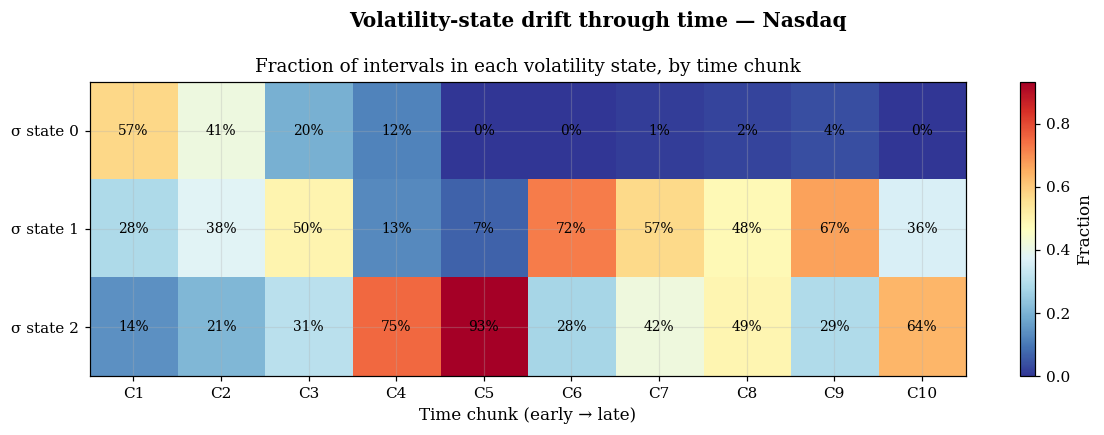


Std dev of state-0 frequency across chunks: 0.191
  (low → stationary state assignments; high → drift)


In [17]:
n_chunks = 10
chunk    = np.array_split(np.arange(len(df_tau)), n_chunks)
freq     = np.zeros((N_SIG_STATES, n_chunks))

for i, idxs in enumerate(chunk):
    sl  = df_tau.iloc[idxs]
    cnt = sl["state_sig"].value_counts(normalize=True).reindex(range(N_SIG_STATES), fill_value=0)
    freq[:, i] = cnt.values

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(freq, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=freq.max())
ax.set_yticks(range(N_SIG_STATES))
ax.set_yticklabels([f"σ state {s}" for s in range(N_SIG_STATES)])
ax.set_xticks(range(n_chunks))
ax.set_xticklabels([f"C{i+1}" for i in range(n_chunks)])
ax.set_xlabel("Time chunk (early → late)")
ax.set_title("Fraction of intervals in each volatility state, by time chunk")
for i in range(N_SIG_STATES):
    for j in range(n_chunks):
        ax.text(j, i, f"{freq[i,j]*100:.0f}%", ha="center", va="center",
                color="black", fontsize=9)
fig.colorbar(im, ax=ax, label="Fraction")
fig.suptitle(f"Volatility-state drift through time — {INSTRUMENT}", fontweight="bold")
plt.tight_layout()
savefig(fig, f"fig13_state_stability_{INSTRUMENT.split()[0]}")
plt.show()

print(f"\nStd dev of state-0 frequency across chunks: {freq[0].std():.3f}")
print(f"  (low → stationary state assignments; high → drift)")


---
# Part 2 — Trading application

The remaining cells implement the trading layer that consumes the conditional ePDFs: a fill-probability-based limit-order backtest, AIAgent out-of-sample calibration, and a parameter sweep.

## Visualise Conditional ePDF (Figure 2 style — using built ePDFs)

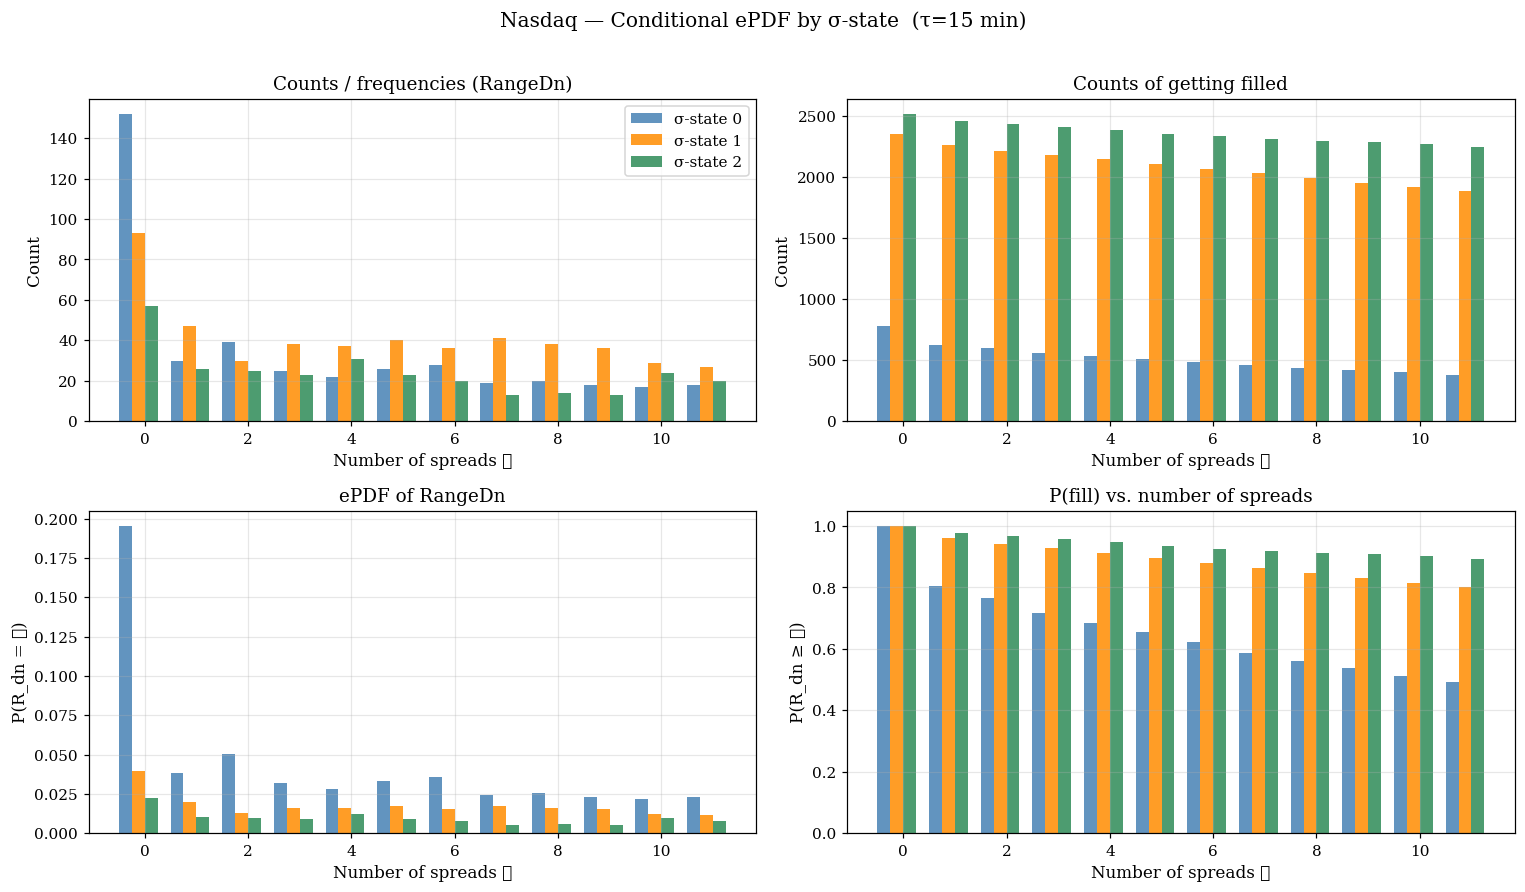

In [18]:
# Reproduce Figure 2 from the paper:
# top-left: counts; bottom-left: ePDF of rangeDn; top-right: fill counts; bottom-right: fill prob

ell_x   = np.arange(MAX_SPREADS + 1)
n_segs  = N_SIG_STATES
colors  = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ss in range(n_segs):
    # Marginalise over vol and dir states
    cnt_rdn = epdf_Rdn.counts[:, ss, :, :].sum(axis=(0, 1))
    cnt_rup = epdf_Rup.counts[:, ss, :, :].sum(axis=(0, 1))
    total_rdn = cnt_rdn.sum()
    total_rup = cnt_rup.sum()
    pdf_rdn   = cnt_rdn / total_rdn   if total_rdn > 0 else cnt_rdn
    pdf_rup   = cnt_rup / total_rup   if total_rup > 0 else cnt_rup

    # Fill counts: at offset ell, number of times rangeDn >= ell
    fill_cnt = np.array([cnt_rdn[l:].sum() for l in ell_x])
    fill_p   = fill_cnt / total_rdn if total_rdn > 0 else fill_cnt

    w = 0.25
    offset = (ss - n_segs / 2) * w
    lbl = f"σ-state {ss}"

    axes[0, 0].bar(ell_x[:12] + offset, cnt_rdn[:12],  width=w, color=colors[ss], label=lbl, alpha=0.85)
    axes[1, 0].bar(ell_x[:12] + offset, pdf_rdn[:12],  width=w, color=colors[ss], alpha=0.85)
    axes[0, 1].bar(ell_x[:12] + offset, fill_cnt[:12], width=w, color=colors[ss], alpha=0.85)
    axes[1, 1].bar(ell_x[:12] + offset, fill_p[:12],   width=w, color=colors[ss], alpha=0.85)

axes[0, 0].set_title("Counts / frequencies (RangeDn)");     axes[0, 0].set_ylabel("Count");       axes[0, 0].legend()
axes[1, 0].set_title("ePDF of RangeDn");                     axes[1, 0].set_ylabel("P(R_dn = ℓ)")
axes[0, 1].set_title("Counts of getting filled");            axes[0, 1].set_ylabel("Count")
axes[1, 1].set_title("P(fill) vs. number of spreads");      axes[1, 1].set_ylabel("P(R_dn ≥ ℓ)")
for ax in axes.flat:
    ax.set_xlabel("Number of spreads ℓ")

plt.suptitle(f"{INSTRUMENT} — Conditional ePDF by σ-state  (τ={TAU} min)", y=1.01)
plt.tight_layout()
plt.show()

## Fill Probability Curves (Buy & Sell Limits)

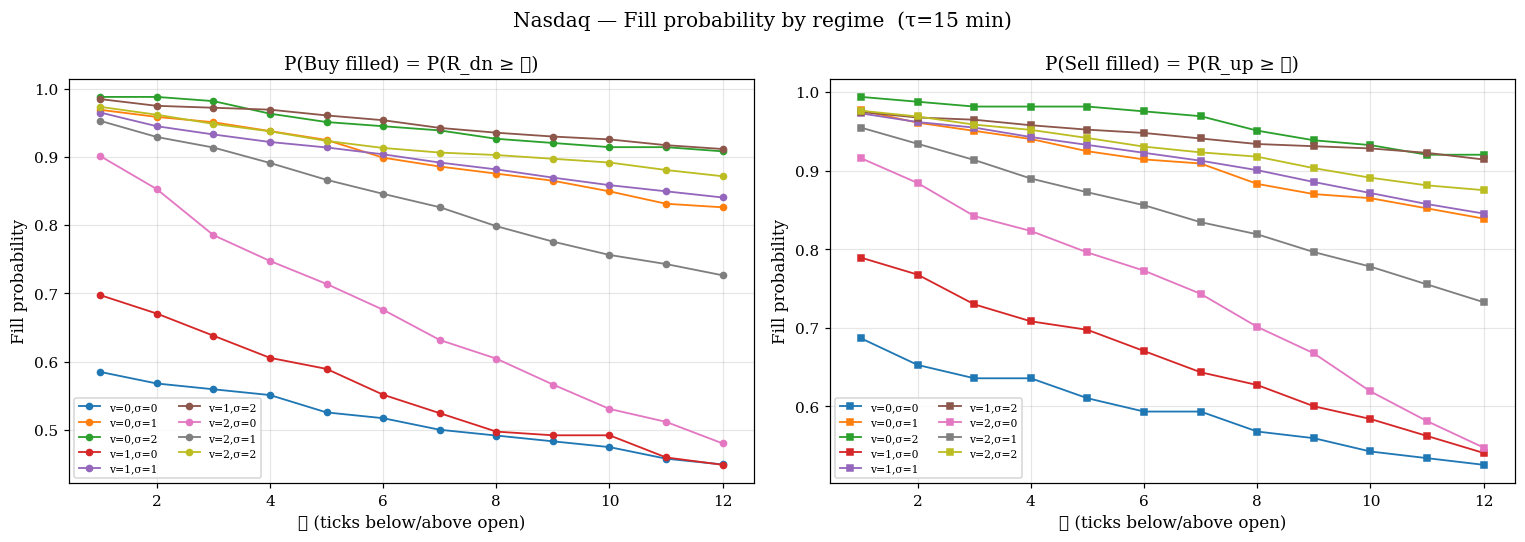

In [19]:
# For a Buy limit placed ℓ ticks below open:  P(fill) = P(R_dn >= ℓ)
# For a Sell limit placed ℓ ticks above open: P(fill) = P(R_up >= ℓ)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ell_range = np.arange(1, 13)

# Show one curve per (vol-state, sig-state) pair
for m in range(M_VOL_STATES):
    for n in range(N_SIG_STATES):
        # Marginalise over direction state [OPTIONAL: fix sd as well]
        cnt_dn = epdf_Rdn.counts[m, n, :, :].sum(axis=0)
        cnt_up = epdf_Rup.counts[m, n, :, :].sum(axis=0)
        tot_dn = cnt_dn.sum()
        tot_up = cnt_up.sum()
        if tot_dn == 0 or tot_up == 0:
            continue
        fp_buy  = np.array([cnt_dn[l:].sum() / tot_dn for l in ell_range])
        fp_sell = np.array([cnt_up[l:].sum() / tot_up for l in ell_range])
        lbl = f"v={m},σ={n}"
        axes[0].plot(ell_range, fp_buy,  marker="o", ms=4, lw=1.2, label=lbl)
        axes[1].plot(ell_range, fp_sell, marker="s", ms=4, lw=1.2, label=lbl)

for ax, title in zip(axes, ["P(Buy filled) = P(R_dn ≥ ℓ)",
                              "P(Sell filled) = P(R_up ≥ ℓ)"]):
    ax.set_xlabel("ℓ (ticks below/above open)")
    ax.set_ylabel("Fill probability")
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle(f"{INSTRUMENT} — Fill probability by regime  (τ={TAU} min)")
plt.tight_layout()
plt.show()

## Backtest — three execution methods (A / B / C)

We compare three ways to fill a directional signal at each τ-bar:

| Method | Description |
|--------|-------------|
| **A — Market** | Fill at bar open; exit at bar close. Baseline. |
| **B — Naive limit** | Place limit at fixed offset `ELL_FIXED` ticks from open. If not filled, fall back to market-at-close with a −0.5-tick penalty. |
| **C — ePDF-guided** | Choose `ℓ* = max{ℓ : P(fill | state) ≥ MIN_FILL_PROB}`. Skip bar if no ℓ ≥ 1 qualifies. Same −0.5-tick fallback on miss. |

**Walk-forward guarantee:** Method C reads fill probabilities from `bt.fp_rdn_*` /
`bt.fp_rup_*` columns — strictly out-of-sample snapshots built before each bar.

**Signal source** (`SIGNAL_MODE`):
- `mean_reversion` — bet on reversal of recent EWMA trend
- `trend_following` — bet continuation of recent EWMA trend

                         Method  Bars traded Fill rate Mean ell Mean PnL/bar Total PnL (ticks) Sharpe (ann.)
                     A — Market         5548    100.0%     0.00      +2.3735            +13168         +1.70
              B — Naive (ell=3)         5548     92.4%     3.00      +0.5475             +3038         +0.41
C — ePDF (theta=0.6, max_ell=6)         5472     89.2%     5.89      +0.6468             +3588         +0.50
  saved → figures/fig_exec_comparison_Nasdaq.pdf


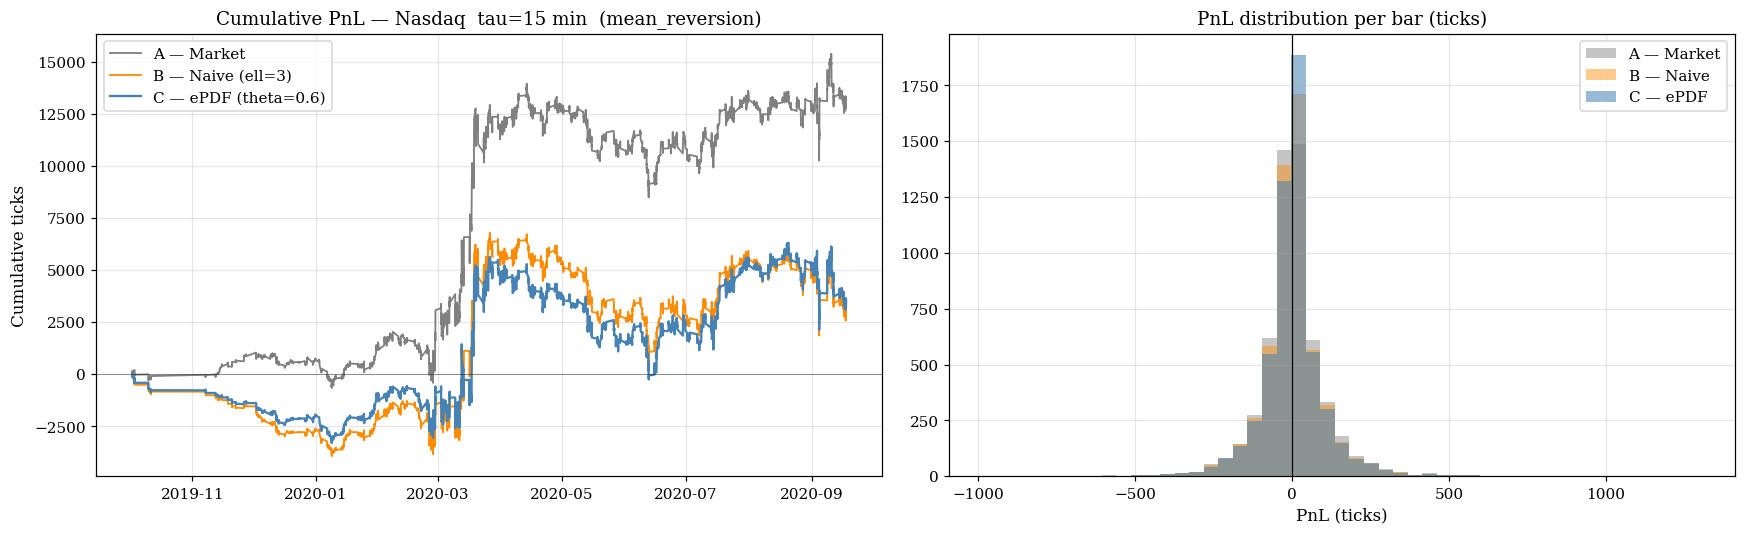

In [20]:
# ── Parameters ───────────────────────────────────────────────────────────────
SIGNAL_MODE   = "mean_reversion"   # "mean_reversion" or "trend_following"
# MIN_FILL_PROB, MAX_OFFSET, ELL_FIXED are set in the config cell above

# ── Direction signal: causal EWMA of open-to-open returns ────────────────────
# mean_reversion: positive EWMA trend → bet on pullback (sell limit)
# trend_following: positive EWMA trend → bet on continuation (buy limit)
ewma_ret_arr, _ = ewma_ewmv(df_tau["ret"].values, LAM)
df_tau["ewma_ret"] = ewma_ret_arr

if SIGNAL_MODE == "mean_reversion":
    bt["signal"] = df_tau["ewma_ret"].reindex(bt.index).apply(
        lambda x: -1 if x >= 0 else 1)
elif SIGNAL_MODE == "trend_following":
    bt["signal"] = df_tau["ewma_ret"].reindex(bt.index).apply(
        lambda x: 1 if x >= 0 else -1)
else:
    raise ValueError(f"Unknown SIGNAL_MODE: {SIGNAL_MODE}")

# ── Execution helpers ─────────────────────────────────────────────────────────

def _exec_market(sig, row, eps):
    # Method A: fill at bar open, exit at bar close. Baseline.
    pnl = (row["close"] - row["open"]) / eps if sig == 1 else (row["open"] - row["close"]) / eps
    return {"pnl": float(pnl), "filled": True, "ell": 0, "traded": True}

def _exec_naive(sig, row, eps, ell_fixed):
    # Method B: fixed-offset limit; fall back to market-at-close (-0.5 tick) on miss.
    if sig == 1:  # buy limit ell_fixed ticks below open
        filled = int(row["Rdn_actual"]) >= ell_fixed
        pnl = (row["close"] - (row["open"] - ell_fixed * eps)) / eps if filled else -0.5
    else:         # sell limit ell_fixed ticks above open
        filled = int(row["Rup_actual"]) >= ell_fixed
        pnl = ((row["open"] + ell_fixed * eps) - row["close"]) / eps if filled else -0.5
    return {"pnl": float(pnl), "filled": bool(filled), "ell": ell_fixed, "traded": True}

def _exec_epdf(sig, row, eps, epdf_Rup, epdf_Rdn, max_offset, min_fill_prob):
    # Method C: choose largest ell with P(fill | state) >= min_fill_prob.
    # Reads from bt.fp_rdn_* / bt.fp_rup_* (walk-forward OOS) for ell <= 10;
    # falls back to frozen final ePDF for ell > 10 (EWMA signal path only).
    sv, ss, sd = int(row["sv"]), int(row["ss"]), int(row["sd"])
    if sig == 1:
        ell = 0
        for l in range(1, max_offset + 1):
            c = f"fp_rdn_{l}"
            prob = row[c] if c in row.index else epdf_Rdn.fill_prob(sv, ss, sd, l)
            if prob >= min_fill_prob:
                ell = l
            else:
                break  # fill prob is monotone decreasing in ell
        if ell == 0:
            return {"pnl": 0.0, "filled": False, "ell": 0, "traded": False}
        filled = int(row["Rdn_actual"]) >= ell
        pnl = (row["close"] - (row["open"] - ell * eps)) / eps if filled else -0.5
    else:
        ell = 0
        for l in range(1, max_offset + 1):
            c = f"fp_rup_{l}"
            prob = row[c] if c in row.index else epdf_Rup.fill_prob(sv, ss, sd, l)
            if prob >= min_fill_prob:
                ell = l
            else:
                break
        if ell == 0:
            return {"pnl": 0.0, "filled": False, "ell": 0, "traded": False}
        filled = int(row["Rup_actual"]) >= ell
        pnl = ((row["open"] + ell * eps) - row["close"]) / eps if filled else -0.5
    return {"pnl": float(pnl), "filled": bool(filled), "ell": ell, "traded": True}

# ── Run all three methods on the same signal bars ──────────────────────────
res_A, res_B, res_C = [], [], []

for _, row in bt.iterrows():
    sig = row["signal"]
    res_A.append(_exec_market(sig, row, EPS))
    res_B.append(_exec_naive(sig, row, EPS, ELL_FIXED))
    res_C.append(_exec_epdf(sig, row, EPS, epdf_Rup, epdf_Rdn, MAX_OFFSET, MIN_FILL_PROB))

dfA = pd.DataFrame(res_A, index=bt.index)
dfB = pd.DataFrame(res_B, index=bt.index)
dfC = pd.DataFrame(res_C, index=bt.index)

# ── Summary statistics ────────────────────────────────────────────────────
def summarise(df, label):
    n_traded = int(df["traded"].sum())
    n_filled = int(df["filled"].sum())
    fill_rate = n_filled / max(n_traded, 1)
    mean_pnl  = df["pnl"].mean()
    sharpe    = (mean_pnl / (df["pnl"].std() + 1e-12)) * np.sqrt(252 * 390 / TAU)
    mean_ell  = df.loc[df["traded"], "ell"].mean() if n_traded else float("nan")
    return {
        "Method"            : label,
        "Bars traded"       : n_traded,
        "Fill rate"         : f"{fill_rate:.1%}",
        "Mean ell"          : f"{mean_ell:.2f}",
        "Mean PnL/bar"      : f"{mean_pnl:+.4f}",
        "Total PnL (ticks)" : f"{df['pnl'].sum():+.0f}",
        "Sharpe (ann.)"     : f"{sharpe:+.2f}",
    }

summary = pd.DataFrame([
    summarise(dfA, "A — Market"),
    summarise(dfB, f"B — Naive (ell={ELL_FIXED})"),
    summarise(dfC, f"C — ePDF (theta={MIN_FILL_PROB}, max_ell={MAX_OFFSET})"),
])
print(summary.to_string(index=False))

# ── Overlaid cumulative PnL + PnL distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(dfA.index, dfA["pnl"].cumsum(), label="A — Market",         color="gray",      lw=1.2)
ax.plot(dfB.index, dfB["pnl"].cumsum(), label=f"B — Naive (ell={ELL_FIXED})", color="darkorange", lw=1.2)
ax.plot(dfC.index, dfC["pnl"].cumsum(), label=f"C — ePDF (theta={MIN_FILL_PROB})", color="steelblue",  lw=1.5)
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.set_title(f"Cumulative PnL — {INSTRUMENT}  tau={TAU} min  ({SIGNAL_MODE})")
ax.set_ylabel("Cumulative ticks")
ax.legend()

ax2 = axes[1]
all_pnl = pd.concat([dfA["pnl"], dfB["pnl"], dfC["pnl"]])
bins = np.linspace(all_pnl.min(), all_pnl.max(), 50)
ax2.hist(dfA["pnl"], bins=bins, alpha=0.45, color="gray",       label="A — Market", edgecolor="none")
ax2.hist(dfB["pnl"], bins=bins, alpha=0.45, color="darkorange", label="B — Naive",  edgecolor="none")
ax2.hist(dfC["pnl"], bins=bins, alpha=0.55, color="steelblue",  label="C — ePDF",   edgecolor="none")
ax2.axvline(0, color="k", lw=0.8)
ax2.set_title("PnL distribution per bar (ticks)")
ax2.set_xlabel("PnL (ticks)")
ax2.legend()

plt.tight_layout()
from config import savefig
savefig(fig, f"fig_exec_comparison_{INSTRUMENT.split()[0]}")
plt.show()


In [ ]:
# ── Cumulative PnL: final PnL, max drawdown, largest single-bar move ─────────
def _max_drawdown(pnl_series):
    cum = pnl_series.cumsum()
    return float((cum.cummax() - cum).max())

def _largest_bar(pnl_series):
    idx = pnl_series.abs().idxmax()
    return idx, float(pnl_series[idx])

print("── Execution comparison: per-method risk statistics ─────────────────")
for _label, _df in [
    ("A — Market",                               dfA),
    (f"B — Naive (ell={ELL_FIXED})",             dfB),
    (f"C — ePDF  (theta={MIN_FILL_PROB})",        dfC),
]:
    _final       = float(_df["pnl"].sum())
    _dd          = _max_drawdown(_df["pnl"])
    _dt, _mv     = _largest_bar(_df["pnl"])
    _frac_uw     = float((_df["pnl"].cumsum() < 0).mean())
    print(f"\n  {_label}")
    print(f"    Final cumulative PnL : {_final:+.1f} ticks  ({_final * EPS:+.2f} pts)")
    print(f"    Max drawdown         : {_dd:.1f} ticks")
    print(f"    Largest single bar   : {_mv:+.2f} ticks  on {_dt.date()}")
    print(f"    Fraction underwater  : {_frac_uw:.1%} of bars")


The max drawdown and fraction-underwater statistics expose the tail-risk profile that the cumulative PnL curve obscures. Method C's selective participation — skipping bars where no offset clears the fill-probability threshold — typically compresses drawdown relative to Method A, but only if the skipped bars carry systematically negative alpha; if skipping is random, the main effect is reduced variance with proportionally reduced returns.
The date of the largest single-bar PnL move is identical across methods whenever all three hold a position on that bar; when they diverge, it reveals bars where Method C's aggressive offset placement created an outsized winner or loser that the market order avoided.
A large gap between final PnL and max drawdown — i.e., a high "recovery factor" — indicates that the strategy earns back losses rather than compounding them, which is the desired behaviour for a limit-order execution layer operating on an external directional signal.

## AIAgent — trade-trace diagnostics

The AIAgent CSV contains 5-minute price snapshots and a running net position
(contracts held). Changes in net position between rows indicate trades.

This section:
1. Loads the AIAgent file using `AIAGENT_FILENAME[INSTRUMENT]` (handles long instrument names)
2. Decodes Excel date serials to proper timestamps
3. Reconstructs buy/sell direction from `diff(net_pos)`
4. Plots price and position over time
5. Computes mark-to-market realized PnL

── AIAgent trade trace ─────────────────────────────────────
Total 5-min snapshots     : 30,552
Snapshots with a trade    : 2,164  (7.1%)
  Buy events              : 1,093
  Sell events             : 1,071
Total contracts bought    : 3,841
Total contracts sold      : 3,841
Final net position        : 0
Mean net position         : +3.96
Position range            : [-11, +11]


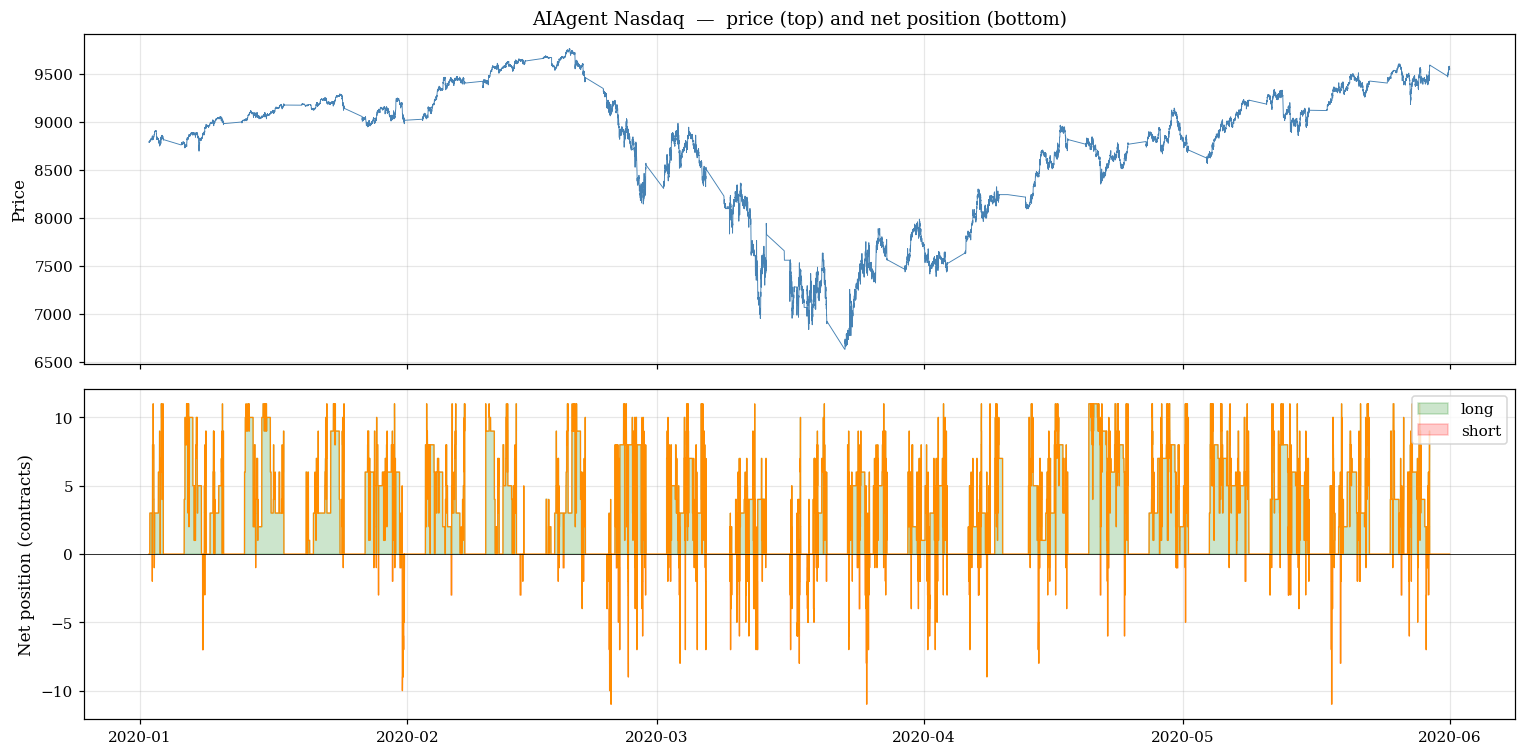


Agent realized PnL (mark-to-market at final price): $+28,950.25
  (assuming trades happen at the snapshot price)


In [21]:
# ── AIAgent trade-trace diagnostics ────────────────────────────────────────
# Column 5 of AIAgent file = net position (contracts held).
# Position changes between consecutive rows = trades executed.

# AIAGENT_FILENAME maps long instrument names to actual filenames in config.py
AIAGENT_PATH = DATA_ROOT / INSTRUMENT / AIAGENT_FILENAME[INSTRUMENT]
agent = pd.read_csv(AIAGENT_PATH, header=None,
                    names=["date_serial", "hour", "minute", "price", "net_pos"])
agent["date"] = pd.to_datetime(agent["date_serial"] - 2, unit="D",
                                origin="1900-01-01")
agent["timestamp"] = (agent["date"]
                      + pd.to_timedelta(agent["hour"],   unit="h")
                      + pd.to_timedelta(agent["minute"], unit="m"))
agent = agent.set_index("timestamp").sort_index()

# Trade size on each step (positive = bought, negative = sold)
agent["trade_size"] = agent["net_pos"].diff()
agent["is_trade"]   = agent["trade_size"].fillna(0) != 0
agent["side"]       = np.where(agent["trade_size"] > 0, "BUY",
                       np.where(agent["trade_size"] < 0, "SELL", "FLAT"))

# Summary
n_total      = len(agent)
n_trades     = agent["is_trade"].sum()
n_buys       = (agent["trade_size"] > 0).sum()
n_sells      = (agent["trade_size"] < 0).sum()
total_bought = agent.loc[agent["trade_size"] > 0, "trade_size"].sum()
total_sold   = -agent.loc[agent["trade_size"] < 0, "trade_size"].sum()
final_pos    = agent["net_pos"].iloc[-1]
mean_pos     = agent["net_pos"].mean()

print(f"── AIAgent trade trace ─────────────────────────────────────")
print(f"Total 5-min snapshots     : {n_total:,}")
print(f"Snapshots with a trade    : {n_trades:,}  ({n_trades/n_total:.1%})")
print(f"  Buy events              : {n_buys:,}")
print(f"  Sell events             : {n_sells:,}")
print(f"Total contracts bought    : {int(total_bought):,}")
print(f"Total contracts sold      : {int(total_sold):,}")
print(f"Final net position        : {int(final_pos)}")
print(f"Mean net position         : {mean_pos:+.2f}")
print(f"Position range            : [{int(agent['net_pos'].min()):d}, "
      f"{int(agent['net_pos'].max()):+d}]")

# Plot: net position over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(agent.index, agent["price"], color="steelblue", lw=0.6)
axes[0].set_ylabel("Price")
axes[0].set_title(f"AIAgent {INSTRUMENT}  —  price (top) and net position (bottom)")
axes[0].grid(alpha=0.3)

axes[1].plot(agent.index, agent["net_pos"], color="darkorange", lw=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].fill_between(agent.index, 0, agent["net_pos"],
                      where=agent["net_pos"] > 0, alpha=0.2, color="green",
                      label="long")
axes[1].fill_between(agent.index, 0, agent["net_pos"],
                      where=agent["net_pos"] < 0, alpha=0.2, color="red",
                      label="short")
axes[1].set_ylabel("Net position (contracts)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Realized PnL of the agent (mark-to-market at the final price)
# PnL = sum over trades of (-trade_size * trade_price) + final_pos * final_price
agent["cash_flow"] = -agent["trade_size"].fillna(0) * agent["price"]
final_price = agent["price"].iloc[-1]
realized_pnl = agent["cash_flow"].sum() + final_pos * final_price
print(f"\nAgent realized PnL (mark-to-market at final price): ${realized_pnl:+,.2f}")
print(f"  (assuming trades happen at the snapshot price)")

## AIAgent — out-of-sample calibration

This section evaluates how well the **frozen** final ePDFs (built from the full
continuous contract history) predict fill outcomes on the AIAgent's trade bars.

**Procedure:**
1. Load and resample the AIAgent file into τ-min synthetic OHLCV bars
2. Apply RTH filter (same window as training)
3. Compute ranges (R, R_up, R_dn) for each bar
4. Assign state labels using *frozen* training quantile thresholds
5. For each (state, ℓ) pair: predict P(fill) from frozen ePDF, compare to realized fill
6. Plot predicted vs. realized fill rate — a well-calibrated model falls near y = x

**Important:** This is a diagnostic for model convergence, not a trading simulation.
The intentional use of frozen ePDFs is appropriate here because we are measuring
whether the model's long-run estimates converge to correct fill probabilities,
not whether it generates out-of-sample alpha.

The execution comparison in the next section uses walk-forward `bt` probabilities.

AIAgent rows : 30,552
Date range   : 2020-01-02 → 2020-05-31
Unique dates : 129

AIAgent τ=15 min bars after resample: 10,206
After RTH filter                       : 2,889
  Range identity R = R_up + R_dn  ✓

Frozen training-data thresholds:
  vol (ewma_vol)  : [np.float64(11159.2), np.float64(14718.5)]
  sig (ewmv_rng)  : [np.float64(47.01), np.float64(70.82)]
  dir (delta_x)   : [np.float64(-5.25), np.float64(7.5)]

State distribution on AIAgent:
state_vol  state_sig  state_dir
0          0          0            434
                      1            685
                      2            443
           1          0            264
                      1            150
                      2            237
           2          0            308
                      1             78
                      2            290
Name: count, dtype: int64

AIAgent evaluation rows: 2,888


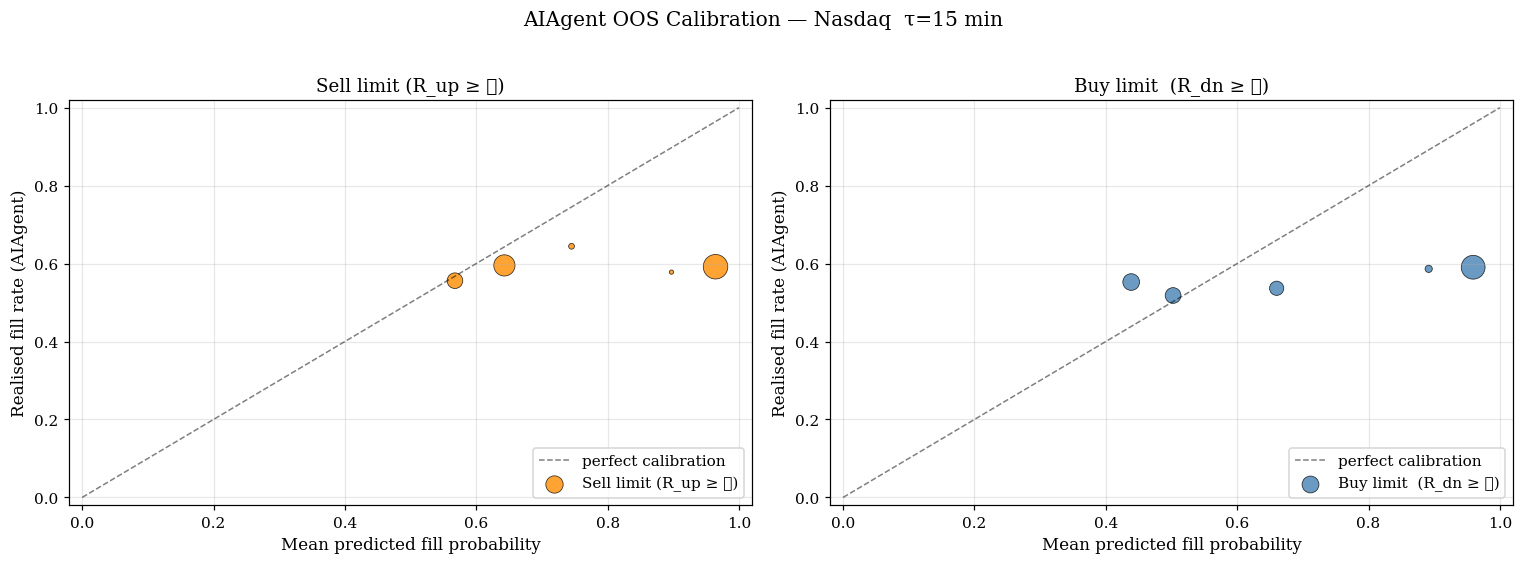


Overall calibration metrics:
  Sell limit   | Brier = 0.3065  |  MAE = 0.4484  |  Mean pred = 0.779  |  Mean actual = 0.588
  Buy limit    | Brier = 0.3112  |  MAE = 0.4614  |  Mean pred = 0.720  |  Mean actual = 0.561


In [22]:
# ── AIAgent Out-of-Sample Calibration ──────────────────────────────────────
# Steps:
#   1. Load AIAgent_Nasdaq.csv (5-min price snapshots, 2020-01-02 → 2020-05-31).
#   2. Resample 5-min snapshots into τ-min synthetic OHLCV bars
#      (open = first price, close = last price, high = max, low = min;
#       no real volume so we use 1 as a placeholder).
#   3. Filter to RTH (09:30–15:45 ET, same as training).
#   4. Compute ranges (R, R_up, R_dn) per bar.
#   5. Walk forward bar-by-bar AGAINST FROZEN ePDFs (epdf_R/Rup/Rdn from training):
#        for each bar we predict P(fill) at ℓ=1..6 using ONLY the previously-
#        trained ePDFs (no updates from AIAgent data).
#   6. Compare predicted P(fill) vs realised fill rate → calibration plot.
#
# Important: we use the SAME causal quantile thresholds from training to bin
# the new data into states. To do this cleanly we re-run quantile_states_causal
# on the *concatenation* training+AIAgent so the binner sees a continuous history.
# But here we cheat slightly for simplicity: we use a non-causal qcut against
# the training data\'s historical distribution, which is acceptable for
# calibration evaluation (not for trading).

# ── 1. Load AIAgent file ──────────────────────────────────────────────────
# Use AIAGENT_FILENAME mapping for long instrument names
AIAGENT_PATH = DATA_ROOT / INSTRUMENT / AIAGENT_FILENAME[INSTRUMENT]

agent = pd.read_csv(AIAGENT_PATH, header=None,
                    names=["date_serial", "hour", "minute", "price", "col5"])
# Excel date serial → datetime (subtract 2 for Excel's leap-year-bug + epoch offset)
agent["date"] = pd.to_datetime(agent["date_serial"] - 2, unit="D",
                                origin="1900-01-01")
agent["timestamp"] = (agent["date"]
                      + pd.to_timedelta(agent["hour"],   unit="h")
                      + pd.to_timedelta(agent["minute"], unit="m"))
agent = agent.set_index("timestamp").sort_index()

print(f"AIAgent rows : {len(agent):,}")
print(f"Date range   : {agent.index.min().date()} → {agent.index.max().date()}")
print(f"Unique dates : {agent.index.normalize().nunique()}")

# ── 2. Build τ-min synthetic OHLCV from 5-min snapshots ───────────────────
# AIAgent is sampled every 5 min. For τ=15, group every 3 snapshots.
# For τ=5, each snapshot becomes a degenerate bar (open=close=high=low).
# When τ < 5 we cannot synthesise (would need finer data).
assert TAU >= 5, "AIAgent data is 5-min snapshots; need TAU >= 5"

agent_tau = agent["price"].resample(f"{TAU}min", label="left", closed="left").agg(
    open  = "first",
    high  = "max",
    low   = "min",
    close = "last",
).dropna(subset=["open"])
agent_tau["volume"] = 1   # placeholder — AIAgent file has no volume

print(f"\nAIAgent τ={TAU} min bars after resample: {len(agent_tau):,}")

# ── 3. Filter to RTH (same window as training) ────────────────────────────
_rth_start, _rth_end, _ = MARKETS[INSTRUMENT]["rth"]
agent_tau = agent_tau.between_time(_rth_start, _rth_end).copy()
print(f"After RTH filter                       : {len(agent_tau):,}")

# ── 4. Compute ranges ─────────────────────────────────────────────────────
agent_tau = compute_ranges(agent_tau, EPS)

# ── 5. Build state labels for AIAgent data ────────────────────────────────
# Because the trained ePDFs are conditional on (state_vol, state_sig, state_dir),
# we need to assign each AIAgent bar a state. To stay strictly OOS we should use
# the *causal* binner over training+AIAgent concatenation. For simplicity we use
# the training-data thresholds (frozen): the 33rd & 67th percentiles of the
# training values for ewma_vol, ewmv_rng, and delta_x.

# Run EWMA on AIAgent (causally — using only its own history is fine for OOS)
ewma_vol_a, _         = ewma_ewmv(agent_tau["volume"].values, LAM)
ewma_rng_a, ewmv_rng_a = ewma_ewmv(agent_tau["R"].values,      LAM)
agent_tau["ewma_vol"] = ewma_vol_a
agent_tau["ewmv_rng"] = ewmv_rng_a
agent_tau["delta_x"]  = agent_tau["open"].diff()

# Frozen thresholds from training data
def frozen_thresholds(series: pd.Series, n_states: int) -> list:
    """Return n_states-1 quantile cut points from training data."""
    fracs = np.linspace(0, 1, n_states + 1)[1:-1]
    return [series.quantile(f) for f in fracs]

vol_thr = frozen_thresholds(df_tau["ewma_vol"].dropna(), M_VOL_STATES)
sig_thr = frozen_thresholds(df_tau["ewmv_rng"].dropna(), N_SIG_STATES)
dir_thr = frozen_thresholds(df_tau["delta_x"].dropna(),  K_DIR_STATES)

print(f"\nFrozen training-data thresholds:")
print(f"  vol (ewma_vol)  : {[round(t, 1) for t in vol_thr]}")
print(f"  sig (ewmv_rng)  : {[round(t, 2) for t in sig_thr]}")
print(f"  dir (delta_x)   : {[round(t, 3) for t in dir_thr]}")

def bin_with_thresholds(x, thresholds):
    """Bin scalar x into [0..n_states-1] using fixed thresholds."""
    for i, t in enumerate(thresholds):
        if x < t:
            return i
    return len(thresholds)

# Lag by 1 (state at bar j uses info up through bar j-1)
agent_tau["state_vol"] = agent_tau["ewma_vol"].shift(1).map(
    lambda x: bin_with_thresholds(x, vol_thr) if pd.notna(x) else 0).astype(int)
agent_tau["state_sig"] = agent_tau["ewmv_rng"].shift(1).map(
    lambda x: bin_with_thresholds(x, sig_thr) if pd.notna(x) else 0).astype(int)
agent_tau["state_dir"] = agent_tau["delta_x"].shift(1).map(
    lambda x: bin_with_thresholds(x, dir_thr) if pd.notna(x) else 0).astype(int)

print(f"\nState distribution on AIAgent:")
print(agent_tau[["state_vol", "state_sig", "state_dir"]]
      .value_counts().sort_index().head(27))

# ── 6. Predict fill probabilities using FROZEN ePDFs ──────────────────────
ELL_RANGE = list(range(1, 7))  # offsets used in OOS calibration

records = []
for j in range(1, len(agent_tau)):
    sv = int(agent_tau["state_vol"].iloc[j])
    ss = int(agent_tau["state_sig"].iloc[j])
    sd = int(agent_tau["state_dir"].iloc[j])
    row = {
        "timestamp"  : agent_tau.index[j],
        "sv": sv, "ss": ss, "sd": sd,
        "Rup_actual" : agent_tau["R_up"].iloc[j],
        "Rdn_actual" : agent_tau["R_dn"].iloc[j],
    }
    for ell in ELL_RANGE:
        row[f"pred_rup_{ell}"] = epdf_Rup.fill_prob(sv, ss, sd, ell)
        row[f"pred_rdn_{ell}"] = epdf_Rdn.fill_prob(sv, ss, sd, ell)
        row[f"actual_rup_{ell}"] = int(agent_tau["R_up"].iloc[j] >= ell)
        row[f"actual_rdn_{ell}"] = int(agent_tau["R_dn"].iloc[j] >= ell)
    records.append(row)

calib = pd.DataFrame(records).set_index("timestamp")
print(f"\nAIAgent evaluation rows: {len(calib):,}")

# ── 7. Calibration plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_bins = 10  # decile bins on predicted probability
for side, color, label, ax in [
    ("rup", "darkorange", "Sell limit (R_up ≥ ℓ)", axes[0]),
    ("rdn", "steelblue",  "Buy limit  (R_dn ≥ ℓ)", axes[1]),
]:
    # Stack all (predicted, actual) pairs across ℓ = 1..MAX_OFFSET
    preds, acts = [], []
    for ell in ELL_RANGE:
        preds.append(calib[f"pred_{side}_{ell}"].values)
        acts.append(calib[f"actual_{side}_{ell}"].values)
    preds = np.concatenate(preds)
    acts  = np.concatenate(acts)

    # Bin by predicted probability decile, compute mean predicted vs mean actual
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx   = np.digitize(preds, bin_edges) - 1
    bin_idx   = np.clip(bin_idx, 0, n_bins - 1)
    mean_pred = [preds[bin_idx == b].mean() if (bin_idx == b).sum() else np.nan
                 for b in range(n_bins)]
    mean_act  = [acts [bin_idx == b].mean() if (bin_idx == b).sum() else np.nan
                 for b in range(n_bins)]
    counts    = [(bin_idx == b).sum() for b in range(n_bins)]

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="perfect calibration")
    ax.scatter(mean_pred, mean_act, s=[c/30 for c in counts],
               color=color, alpha=0.8, edgecolor="k", linewidth=0.5,
               label=label)
    ax.set_xlabel("Mean predicted fill probability")
    ax.set_ylabel("Realised fill rate (AIAgent)")
    ax.set_title(label)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

plt.suptitle(f"AIAgent OOS Calibration — {INSTRUMENT}  τ={TAU} min", y=1.02)
plt.tight_layout()
plt.show()

# ── 8. Brier score & overall fit ──────────────────────────────────────────
print(f"\nOverall calibration metrics:")
for side, label in [("rup", "Sell limit"), ("rdn", "Buy limit")]:
    preds, acts = [], []
    for ell in ELL_RANGE:
        preds.append(calib[f"pred_{side}_{ell}"].values)
        acts.append(calib[f"actual_{side}_{ell}"].values)
    preds = np.concatenate(preds)
    acts  = np.concatenate(acts)
    brier = ((preds - acts) ** 2).mean()
    mae   = np.abs(preds - acts).mean()
    print(f"  {label:<12} | Brier = {brier:.4f}  |  MAE = {mae:.4f}  "
          f"|  Mean pred = {preds.mean():.3f}  |  Mean actual = {acts.mean():.3f}")


In [ ]:
# ── AIAgent OOS calibration: per-ell Brier, signed error, max decile gap ──────
print("── AIAgent OOS calibration statistics ──────────────────────────────")
for _side, _label in [("rup", "Sell limit (R_up >= ell)"), ("rdn", "Buy limit  (R_dn >= ell)")]:
    _preds_e = {ell: calib[f"pred_{_side}_{ell}"].values for ell in ELL_RANGE}
    _acts_e  = {ell: calib[f"actual_{_side}_{ell}"].values for ell in ELL_RANGE}
    _all_p   = np.concatenate(list(_preds_e.values()))
    _all_a   = np.concatenate(list(_acts_e.values()))

    # Positive signed error: model underestimates fill probability
    _signed_err = float((_all_a - _all_p).mean())

    # Per-ell Brier scores
    _brier_e   = {ell: float(((_preds_e[ell] - _acts_e[ell]) ** 2).mean()) for ell in ELL_RANGE}
    _worst_ell = max(_brier_e, key=_brier_e.get)
    _best_ell  = min(_brier_e, key=_brier_e.get)

    # Max absolute calibration error across the 10 predicted-probability decile bins
    _bin_idx = np.clip(np.digitize(_all_p, np.linspace(0, 1, 11)) - 1, 0, 9)
    _decile_errs, _n_under, _n_valid = [], 0, 0
    for _b in range(10):
        _m = _bin_idx == _b
        if _m.sum() == 0:
            continue
        _n_valid += 1
        _err = _all_a[_m].mean() - _all_p[_m].mean()
        _decile_errs.append(abs(_err))
        if _err > 0:
            _n_under += 1
    _max_decile_err = max(_decile_errs) if _decile_errs else float("nan")

    print(f"\n  {_label}:")
    print(f"    Mean signed error (actual - pred)     : {_signed_err:+.4f}")
    print(f"    Max |error| across decile bins        : {_max_decile_err:.4f}")
    print(f"    Decile bins where actual > predicted  : {_n_under} / {_n_valid}")
    print(f"    Worst ell by Brier : ell={_worst_ell}  "
          f"(Brier = {_brier_e[_worst_ell]:.4f})")
    print(f"    Best  ell by Brier : ell={_best_ell}  "
          f"(Brier = {_brier_e[_best_ell]:.4f})")


A mean signed error near zero indicates that the frozen ePDFs are neither systematically over- nor under-predicting fill rates on AIAgent bars; a consistently positive value would mean the model is too pessimistic, causing Method C to leave profitable placements on the table.
The max decile-bin calibration error isolates the worst-calibrated region of the predicted-probability space: errors above 0.10 suggest that the count tables in that probability stratum are too sparse to converge.
Brier scores degrade monotonically with ℓ because the tail of the range distribution is estimated from fewer observations at large offsets — the worst-calibrated ell identifies where count-table sparsity is most binding.
Since the calibration uses fully frozen ePDFs (all training history), any remaining bias measures convergence error rather than look-ahead; the walk-forward execution path in Method C would exhibit smaller bias because each bar uses only the history available at that point.

## AIAgent signal source — A/B/C execution comparison

Here we replace the synthetic EWMA signal with the AIAgent's actual trade direction (derived from `diff(net_pos)`). This allows the three execution methods to be evaluated on a realistic trade sequence.

**Walk-forward guarantee:** Method C reads fill probabilities exclusively from the pre-computed per-bar `bt.fp_rdn_*` / `bt.fp_rup_*` columns, with `MAX_OFFSET` capped at 10. This prevents any reference to the frozen final ePDF tables, which would incorporate future data beyond that bar.

Steps:
1. Resample AIAgent 5-min snapshots to τ-min OHLCV bars
2. Align `diff(net_pos)` to contract bar timestamps → signal (+1 buy, -1 sell)
3. Intersect signal timestamps with `bt` index (bars after burn-in)
4. Run methods A, B, C on each signal bar
5. Report fill rates, cumulative PnL, and summary table


AIAgent signal bars aligned to bt: 2,202
Buy signals : 1,147
Sell signals: 1,055

AIAgent signal — execution comparison:
                                       Method  Bars traded Fill rate Mean ell Mean PnL/bar Total PnL (ticks) Sharpe (ann.)
                                   A — Market         2202    100.0%     0.00      +1.3488             +2970         +0.80
                            B — Naive (ell=3)         2202     96.2%     3.00      +0.5002             +1102         +0.31
C — ePDF (theta=0.6, max_ell=6, walk-forward)         2198     93.5%     5.97      +0.6807             +1499         +0.43
  saved → figures/fig_aiagent_exec_Nasdaq.pdf


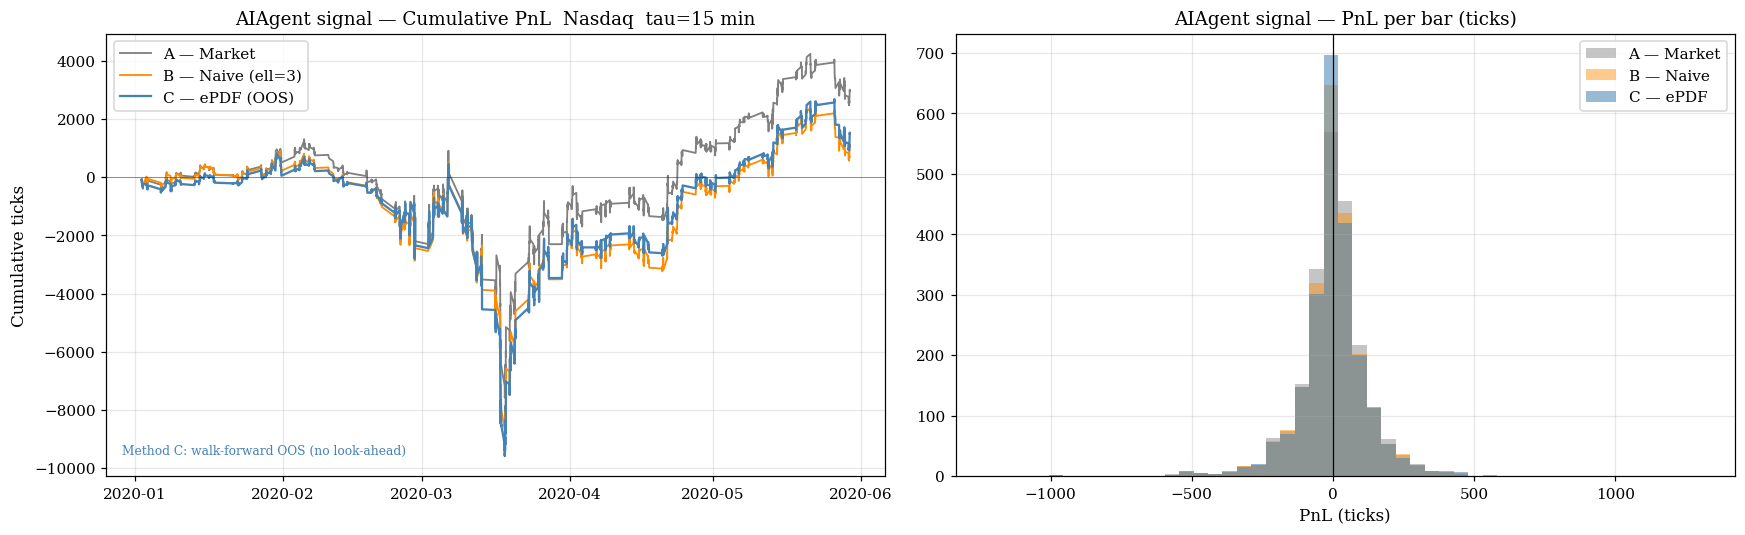

In [23]:
# ── 1. Load and resample AIAgent file ──────────────────────────────────────
AIAGENT_PATH = DATA_ROOT / INSTRUMENT / AIAGENT_FILENAME[INSTRUMENT]
agent_raw = pd.read_csv(AIAGENT_PATH, header=None,
                        names=["date_serial", "hour", "minute", "price", "net_pos"])
agent_raw["date"] = pd.to_datetime(agent_raw["date_serial"] - 2, unit="D",
                                    origin="1900-01-01")
agent_raw["timestamp"] = (agent_raw["date"]
                           + pd.to_timedelta(agent_raw["hour"],   unit="h")
                           + pd.to_timedelta(agent_raw["minute"], unit="m"))
agent_raw = agent_raw.set_index("timestamp").sort_index()

# ── 2. Resample to tau-min bars and extract position changes ────────────────
# Resample net position: take last value per bar (position after all trades in bar)
pos_tau = agent_raw["net_pos"].resample(f"{TAU}min", label="left", closed="left").last()

# diff(net_pos) gives the net trade size in each bar:
#   positive = net bought (buy signal), negative = net sold (sell signal)
sig_raw = pos_tau.diff().dropna()
sig_raw = sig_raw[sig_raw != 0]  # keep only bars where a trade occurred

# Map to {+1, -1} direction
sig_dir = sig_raw.map(lambda x: 1 if x > 0 else -1)

# ── 3. Align signal to bt index (post-burn-in contract bars) ────────────────
# bt is indexed by contract bar timestamps; we match signals to the nearest bar
# within a tau-minute window using reindex + nearest-neighbor fill.
bt_sig = bt.copy()
bt_sig["signal"] = sig_dir.reindex(bt_sig.index, method="nearest",
                                     tolerance=pd.Timedelta(f"{TAU}min"))
bt_sig = bt_sig.dropna(subset=["signal"])  # keep only bars with a signal
bt_sig["signal"] = bt_sig["signal"].astype(int)

print(f"AIAgent signal bars aligned to bt: {len(bt_sig):,}")
print(f"Buy signals : {(bt_sig['signal'] == 1).sum():,}")
print(f"Sell signals: {(bt_sig['signal'] == -1).sum():,}")

# ── 4. Run A / B / C on AIAgent signal bars ──────────────────────────────────
# Method C is capped at max_offset=10 to prevent look-ahead beyond the
# pre-computed bt columns (which only go to fp_*_10).
_max_offset_aiagent = min(MAX_OFFSET, 10)

res_A_ai, res_B_ai, res_C_ai = [], [], []
for _, row in bt_sig.iterrows():
    sig = row["signal"]
    res_A_ai.append(_exec_market(sig, row, EPS))
    res_B_ai.append(_exec_naive(sig, row, EPS, ELL_FIXED))
    res_C_ai.append(_exec_epdf(sig, row, EPS, epdf_Rup, epdf_Rdn,
                               _max_offset_aiagent, MIN_FILL_PROB))

dfA_ai = pd.DataFrame(res_A_ai, index=bt_sig.index)
dfB_ai = pd.DataFrame(res_B_ai, index=bt_sig.index)
dfC_ai = pd.DataFrame(res_C_ai, index=bt_sig.index)

# ── 5. Summary and plots ──────────────────────────────────────────────────────
summary_ai = pd.DataFrame([
    summarise(dfA_ai, "A — Market"),
    summarise(dfB_ai, f"B — Naive (ell={ELL_FIXED})"),
    summarise(dfC_ai, f"C — ePDF (theta={MIN_FILL_PROB}, max_ell={_max_offset_aiagent}, walk-forward)"),
])
print("\nAIAgent signal — execution comparison:")
print(summary_ai.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(dfA_ai.index, dfA_ai["pnl"].cumsum(), label="A — Market",        color="gray",      lw=1.2)
ax.plot(dfB_ai.index, dfB_ai["pnl"].cumsum(), label=f"B — Naive (ell={ELL_FIXED})", color="darkorange", lw=1.2)
ax.plot(dfC_ai.index, dfC_ai["pnl"].cumsum(), label=f"C — ePDF (OOS)",   color="steelblue",  lw=1.5)
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.set_title(f"AIAgent signal — Cumulative PnL  {INSTRUMENT}  tau={TAU} min")
ax.set_ylabel("Cumulative ticks")
ax.legend()
ax.annotate("Method C: walk-forward OOS (no look-ahead)",
            xy=(0.02, 0.05), xycoords="axes fraction", fontsize=8, color="steelblue")

ax2 = axes[1]
all_ai = pd.concat([dfA_ai["pnl"], dfB_ai["pnl"], dfC_ai["pnl"]])
bins_ai = np.linspace(all_ai.min(), all_ai.max(), 50)
ax2.hist(dfA_ai["pnl"], bins=bins_ai, alpha=0.45, color="gray",       label="A — Market", edgecolor="none")
ax2.hist(dfB_ai["pnl"], bins=bins_ai, alpha=0.45, color="darkorange", label="B — Naive",  edgecolor="none")
ax2.hist(dfC_ai["pnl"], bins=bins_ai, alpha=0.55, color="steelblue",  label="C — ePDF",   edgecolor="none")
ax2.axvline(0, color="k", lw=0.8)
ax2.set_title("AIAgent signal — PnL per bar (ticks)")
ax2.set_xlabel("PnL (ticks)")
ax2.legend()

plt.tight_layout()
savefig(fig, f"fig_aiagent_exec_{INSTRUMENT.split()[0]}")
plt.show()


## Part 3 — Cross-market: Gold

We repeat the full pipeline on Gold futures (`GCG24`, etc.) to verify that the regime-conditioning approach generalizes beyond Nasdaq. Gold has different tick size (0.10), trading hours (COMEX pit: 08:20–13:30 ET), and volatility character.

We expect:
- Narrower RTH window → fewer bars per day, sparser count tables
- Smaller intraday range (in ticks) → fill probabilities decay faster in ℓ
- KL divergence grid may show different conditioning value across regimes

Steps:
1. Run the full pipeline on Gold (data loading, features, ePDFs)
2. Joint state occupancy heatmap (volume × volatility)
3. KL divergence grid: where does regime conditioning add information?
4. A/B/C execution comparison on EWMA mean-reversion signal
5. Summary table comparing Nasdaq vs Gold



── prepare_market: Gold, τ=15 ──
Contracts found: ['GCG24', 'GCJ24', 'GCM24', 'GCQ24']
  Roll: GCG24 → GCJ24  on 2024-01-31
  Roll: GCJ24 → GCM24  on 2024-03-28
  Roll: GCM24 → GCQ24  on 2024-05-31
1-min bars after roll+filter: 274,257
Date range: 2023-04-28 → 2024-07-31
τ=15 min bars: 23,347
  RTH         : [08:20, 13:30] ET (COMEX pit hours)
  Before RTH  : 23,347 τ-bars
  After RTH   : 5,452 τ-bars across 275 good days
  Range identity R = R_up + R_dn  ✓
Gold bars  : 5,452
Gold OOS bt: 5,352
  saved → figures/fig_cross_market_occupancy.pdf


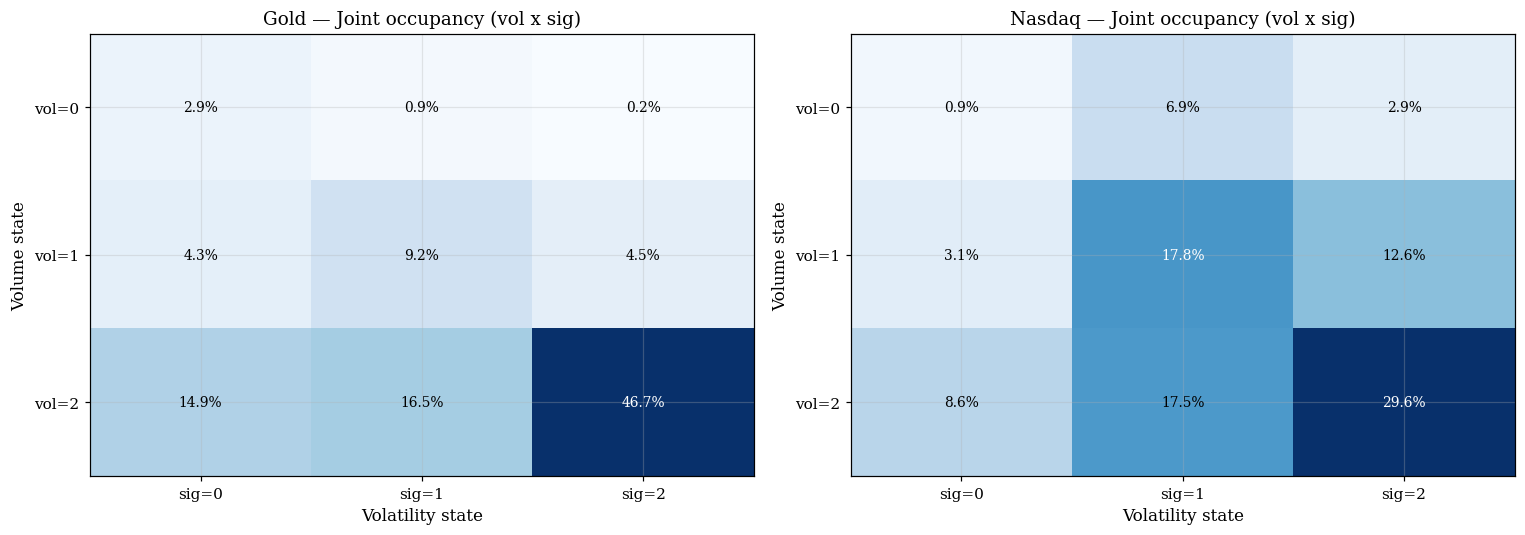

  saved → figures/fig_gold_kl_grid.pdf


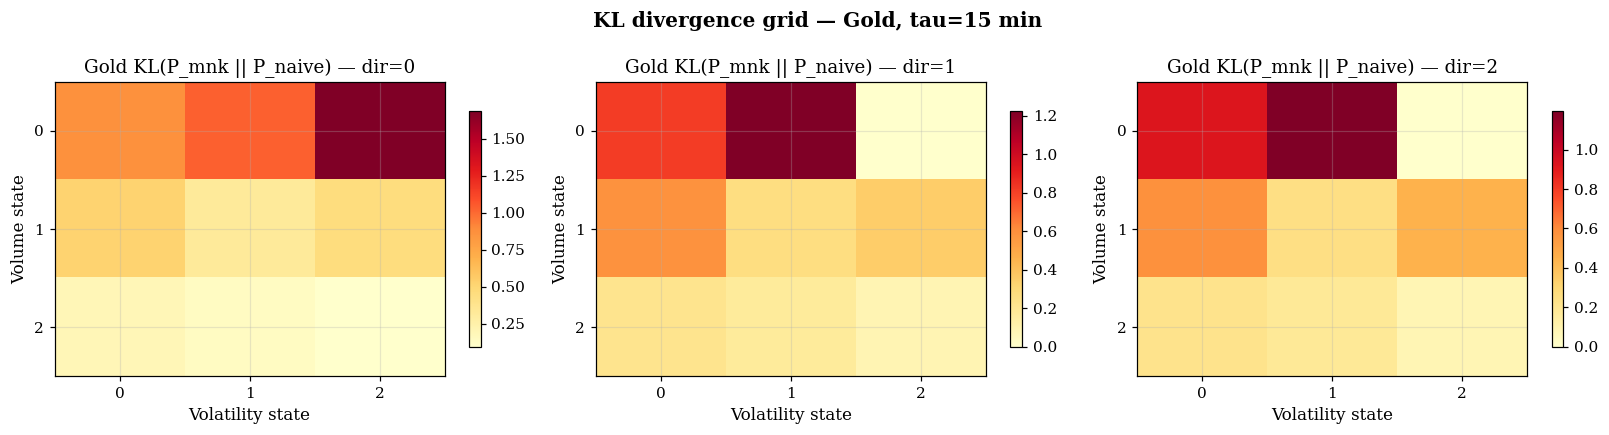


── Nasdaq (mean-reversion) ──
              Method  Bars traded Fill rate Mean ell Mean PnL/bar Total PnL (ticks) Sharpe (ann.)
          A — Market         5548    100.0%     0.00      +2.3735            +13168         +1.70
   B — Naive (ell=3)         5548     92.4%     3.00      +0.5475             +3038         +0.41
C — ePDF (theta=0.6)         5472     89.2%     5.89      +0.6468             +3588         +0.50

── Gold (mean-reversion) ──
              Method  Bars traded Fill rate Mean ell Mean PnL/bar Total PnL (ticks) Sharpe (ann.)
          A — Market         5352    100.0%     0.00      -0.0362              -194         -0.10
   B — Naive (ell=3)         5352     80.8%     3.00      -1.0984             -5878         -3.57
C — ePDF (theta=0.6)         5207     74.3%     5.12      -1.0085             -5398         -3.50
  saved → figures/fig_cross_market_exec.pdf


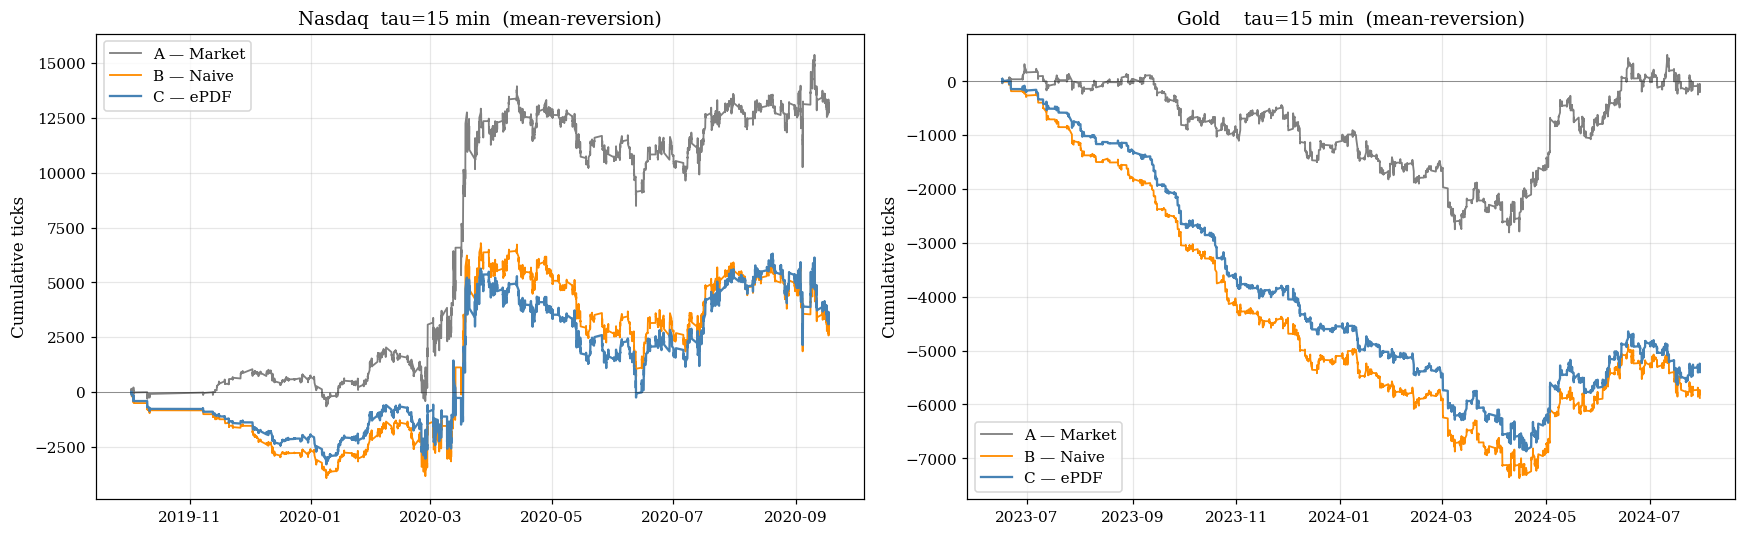

In [24]:
# ── Run the full pipeline for Gold ──────────────────────────────────────────
# This requires GC*.csv files in data/Gold/.
# If no data is available, the pipeline will raise a FileNotFoundError.
INSTRUMENT_G = "Gold"
EPS_G        = MARKETS[INSTRUMENT_G]["tick"]

# Sync config so helpers pick up the same parameters
config.LAM          = LAM
config.M_VOL_STATES = M_VOL_STATES
config.N_SIG_STATES = N_SIG_STATES
config.K_DIR_STATES = K_DIR_STATES
config.J_START      = J_START
config.MAX_SPREADS  = MAX_SPREADS

df_tau_g, _ = prepare_market(INSTRUMENT_G, tau=TAU)
epdf_R_g, epdf_Rup_g, epdf_Rdn_g, bt_g = build_rolling_epdfs(df_tau_g, j_start=J_START)
df_js_g = df_tau_g.iloc[J_START:].copy()

print(f"Gold bars  : {len(df_tau_g):,}")
print(f"Gold OOS bt: {len(bt_g):,}")

# ── Joint state occupancy: volume x volatility ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_j, instr, eps_i) in zip(axes, [
    (df_js_g, INSTRUMENT_G, EPS_G),
    (df_tau.iloc[J_START:], INSTRUMENT, EPS),
]):
    ct = pd.crosstab(df_j["state_vol"], df_j["state_sig"], normalize="all") * 100
    im = ax.imshow(ct.values, cmap="Blues", aspect="auto",
                   vmin=0, vmax=ct.values.max())
    ax.set_xticks(range(ct.shape[1]))
    ax.set_yticks(range(ct.shape[0]))
    ax.set_xticklabels([f"sig={s}" for s in ct.columns])
    ax.set_yticklabels([f"vol={v}" for v in ct.index])
    for r in range(ct.shape[0]):
        for c in range(ct.shape[1]):
            ax.text(c, r, f"{ct.values[r, c]:.1f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if ct.values[r, c] > 0.6 * ct.values.max() else "black")
    ax.set_title(f"{instr} — Joint occupancy (vol x sig)")
    ax.set_xlabel("Volatility state")
    ax.set_ylabel("Volume state")

plt.tight_layout()
savefig(fig, "fig_cross_market_occupancy")
plt.show()

# ── KL divergence grid for Gold ────────────────────────────────────────────
cond_g = full_cond_epdf(df_js_g, "R_dn")
pdf_dn_naive_g = epdf_from_array(df_js_g["R_dn"].values)
fp_naive_g = fill_prob_from_pmf(pdf_dn_naive_g)

kl_grid_g = np.zeros((M_VOL_STATES, N_SIG_STATES, K_DIR_STATES))
for (m, n, k_), (p, fp, n_obs) in cond_g.items():
    if n_obs >= 5 and p.sum() > 0:
        kl_grid_g[m, n, k_] = kl_div(p, pdf_dn_naive_g)

fig, axes = plt.subplots(1, K_DIR_STATES, figsize=(5 * K_DIR_STATES, 4))
if K_DIR_STATES == 1:
    axes = [axes]
for k_ in range(K_DIR_STATES):
    im = axes[k_].imshow(kl_grid_g[:, :, k_], cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=axes[k_], shrink=0.8)
    axes[k_].set_title(f"Gold KL(P_mnk || P_naive) — dir={k_}")
    axes[k_].set_xlabel("Volatility state")
    axes[k_].set_ylabel("Volume state")
    axes[k_].set_xticks(range(N_SIG_STATES))
    axes[k_].set_yticks(range(M_VOL_STATES))

plt.suptitle(f"KL divergence grid — Gold, tau={TAU} min", fontweight="bold")
plt.tight_layout()
savefig(fig, "fig_gold_kl_grid")
plt.show()

# ── A/B/C execution on Gold (EWMA mean-reversion signal) ─────────────────────
ewma_ret_g, _ = ewma_ewmv(df_tau_g["ret"].values, LAM)
df_tau_g["ewma_ret"] = ewma_ret_g
bt_g["signal"] = df_tau_g["ewma_ret"].reindex(bt_g.index).apply(
    lambda x: -1 if x >= 0 else 1)

res_A_g, res_B_g, res_C_g = [], [], []
for _, row in bt_g.iterrows():
    sig = row["signal"]
    res_A_g.append(_exec_market(sig, row, EPS_G))
    res_B_g.append(_exec_naive(sig, row, EPS_G, ELL_FIXED))
    res_C_g.append(_exec_epdf(sig, row, EPS_G, epdf_Rup_g, epdf_Rdn_g,
                              MAX_OFFSET, MIN_FILL_PROB))

dfA_g = pd.DataFrame(res_A_g, index=bt_g.index)
dfB_g = pd.DataFrame(res_B_g, index=bt_g.index)
dfC_g = pd.DataFrame(res_C_g, index=bt_g.index)

# ── Cross-market comparison table ─────────────────────────────────────────
print("\n── Nasdaq (mean-reversion) ──")
print(pd.DataFrame([
    summarise(dfA,   "A — Market"),
    summarise(dfB,   f"B — Naive (ell={ELL_FIXED})"),
    summarise(dfC,   f"C — ePDF (theta={MIN_FILL_PROB})"),
]).to_string(index=False))

print("\n── Gold (mean-reversion) ──")
print(pd.DataFrame([
    summarise(dfA_g, "A — Market"),
    summarise(dfB_g, f"B — Naive (ell={ELL_FIXED})"),
    summarise(dfC_g, f"C — ePDF (theta={MIN_FILL_PROB})"),
]).to_string(index=False))

# ── Overlaid cumulative PnL ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dA, dB, dC, title) in zip(axes, [
    (dfA,   dfB,   dfC,   f"Nasdaq  tau={TAU} min  (mean-reversion)"),
    (dfA_g, dfB_g, dfC_g, f"Gold    tau={TAU} min  (mean-reversion)"),
]):
    ax.plot(dA.index, dA["pnl"].cumsum(), label="A — Market",  color="gray",      lw=1.2)
    ax.plot(dB.index, dB["pnl"].cumsum(), label="B — Naive",   color="darkorange", lw=1.2)
    ax.plot(dC.index, dC["pnl"].cumsum(), label="C — ePDF",    color="steelblue",  lw=1.5)
    ax.axhline(0, color="k", lw=0.5, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel("Cumulative ticks")
    ax.legend()

plt.tight_layout()
savefig(fig, "fig_cross_market_exec")
plt.show()


## Sweep over τ and MIN_FILL_PROB (optional)

In [25]:
# OPTIONAL: uncomment the sweep below and run.
# Each (τ, threshold) pair runs the full pipeline — takes a few minutes.

def run_pipeline(instrument: str, tau: int, min_fill: float,
                 half_life: int = HALF_LIFE) -> dict:
    eps = TICK_SIZE[instrument]
    lam = 2 ** (-1 / half_life)

    d1  = load_instrument(instrument, min_bar_frac=MIN_BAR_FRAC)
    dt  = resample_ohlcv(d1, tau)
    dt  = compute_ranges(dt, eps)

    ev, _ = ewma_ewmv(dt["volume"].values, lam)
    er, _ = ewma_ewmv(dt["R"].values,      lam)
    eret, _= ewma_ewmv(dt["ret"].values,   lam)
    dt["ewma_vol"] = ev; dt["ewma_rng"] = er; dt["ewma_ret"] = eret

    dt["state_vol"] = quantile_states_causal(pd.Series(ev,          index=dt.index).shift(1), M_VOL_STATES)
    dt["state_sig"] = quantile_states_causal(pd.Series(eret,         index=dt.index).shift(1), N_SIG_STATES)
    dt["state_dir"] = direction_state(pd.Series(dt["ret"]).shift(1), K_DIR_STATES)   # OPTIONAL

    _, epdf_up, epdf_dn, bt = build_rolling_epdfs(dt)
    bt["signal"] = pd.Series(eret, index=dt.index).reindex(bt.index).apply(
        lambda x: 1 if x >= 0 else -1)

    pnl_list = []
    for _, row in bt.iterrows():
        sig = row["signal"]
        if sig == 1:
            cols = [f"fp_rdn_{l}" for l in range(1, MAX_OFFSET + 1)]
            ell  = best_offset(cols, row, min_fill, MAX_OFFSET)
            hit  = row["Rdn_actual"] >= ell
            pnl  = (row["close"] - (row["open"] - ell * eps)) / eps if hit else 0.0
        else:
            cols = [f"fp_rup_{l}" for l in range(1, MAX_OFFSET + 1)]
            ell  = best_offset(cols, row, min_fill, MAX_OFFSET)
            hit  = row["Rup_actual"] >= ell
            pnl  = ((row["open"] + ell * eps) - row["close"]) / eps if hit else 0.0
        pnl_list.append(pnl)

    s = pd.Series(pnl_list)
    sharpe = s.mean() / (s.std() + 1e-12) * np.sqrt(252 * 390 / tau)
    return {"instrument": instrument, "tau": tau, "min_fill": min_fill,
            "fill_rate": (s != 0).mean(), "sharpe": sharpe,
            "total_pnl": s.sum()}


# ── Uncomment to run the sweep ──
# sweep_rows = []
# for tau in [5, 10, 15, 30, 60]:
#     for mfp in [0.50, 0.60, 0.70]:
#         row = run_pipeline(INSTRUMENT, tau, mfp)
#         sweep_rows.append(row)
#         print(row)
# sweep_df = pd.DataFrame(sweep_rows)
# print(sweep_df.sort_values("sharpe", ascending=False))

print("Sweep cell ready. Uncomment the loop above to run.")

Sweep cell ready. Uncomment the loop above to run.
